<a href="https://colab.research.google.com/github/JoseAlberto88/Dry-Bean-Classification/blob/main/Beans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dry Bean Classification. DAMO510 Final Project (Winter 2026)

## Project Overview

This repository contains the final project for DAMO510 (Winter 2026), submitted by a team of three students: Manpreet Kaur, Vanessa Arellano Macedo and José Alberto Martinez Morales,. The final project integrates the regression, classification, and time series skills developed throughout the course into a single, self-directed analysis: selecting a dataset, designing an end-to-end workflow, and presenting the results as reproducible code, a written report, and a recorded presentation.

The assignment brief permits regression, classification, time series, or a combination of these problem types. The team elected to commit to a single, well-executed **multiclass classification** task rather than combine problem types artificially. The chosen dataset, *the Dry Bean Dataset*, was purpose-built for classification: it has no separate natural continuous target to regress against, and it carries no temporal dimension, which rules out a time series component. Depth on one problem, applied thoroughly across the full CRISP-DM cycle, was judged preferable to spreading effort thinly across problem types the data does not naturally support.

The work follows the CRISP-DM methodology end to end: *Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, and Deployment/Reflection*, and the deliverables are submitted as five separate files: the original dataset, the cleaned and transformed dataset, the Python code (Jupyter notebook), the written report (approximatelly 20 pages, APA format), and a 10-minute recorded presentation with all three team members speaking.

## The Dataset

The project uses the **Dry Bean Dataset** from the UCI Machine Learning Repository (dataset #602), originally published by Koklu and Ozkan (2020) in *Computers and Electronics in Agriculture*, 174, 105507. The dataset was produced from high-resolution camera images of 13,611 dry bean grains spanning seven registered varieties, with 16 geometric shape and dimension features extracted from each grain via computer vision (area, perimeter, axis lengths, eccentricity, solidity, roundness, compactness, and four derived shape factors, among others).

Key characteristics:

- **Size:** 13,611 rows × 17 columns (16 features + target), comfortably exceeding the assignment's minimum of 1,000 rows and 10 columns.
- **Target:** `Class`. Seven bean varieties (Seker, Barbunya, Bombay, Cali, Dermason, Horoz, Sira).
- **Class balance and multicollinearity:** the dataset is known to have an underrepresented class (Bombay) and strong correlation among its size-derived features (Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, EquivDiameter all describe the same physical bean size). Both properties are treated as findings to confirm and quantify during Data Understanding rather than assumptions carried in unexamined.
- **Sourcing:** the assignment brief prefers datasets from open data portals, government sources, or original data collection over Kaggle or GitHub, listing UCI only as a fallback. This dataset is not sourced from Kaggle or GitHub, and it is a peer-reviewed benchmark dataset with a published, citable methodology rather than an unvetted scraped mirror. A distinction the report's Data Understanding section addresses directly rather than leaving implicit.

Source: [UCI Machine Learning Repository, Dry Bean Dataset](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset)


In [1]:
# Importing the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Load the original dataset
import os
import io
import zipfile
import requests
import pandas as pd

PROJECT_DIR = '/content/drive/MyDrive/DAMO510 Final Project'
ORIGINAL_XLSX = os.path.join(PROJECT_DIR, 'DAMO510_FinalProject_TeamJMV_Dataset_Original.xlsx')
UCI_ZIP_URL = 'https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip'

os.makedirs(PROJECT_DIR, exist_ok=True)

if not os.path.exists(ORIGINAL_XLSX):
    print(f"Original dataset not found in Drive -- downloading from UCI:\n  {UCI_ZIP_URL}")
    resp = requests.get(UCI_ZIP_URL, timeout=60)
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        # Find the .xlsx member regardless of exact folder nesting inside the zip
        xlsx_members = [m for m in z.namelist() if m.lower().endswith('.xlsx')]
        if not xlsx_members:
            raise FileNotFoundError(f"No .xlsx file found inside the UCI zip. Contents: {z.namelist()}")
        member = xlsx_members[0]
        with z.open(member) as src, open(ORIGINAL_XLSX, 'wb') as dst:
            dst.write(src.read())
    print(f"Saved untouched original file to:\n  {ORIGINAL_XLSX}")
else:
    print(f"Original dataset already present in Drive:\n  {ORIGINAL_XLSX}")

df = pd.read_excel(ORIGINAL_XLSX)
print("\nLoaded dataset from:", ORIGINAL_XLSX)
print("Shape (rows, columns):", df.shape)


Original dataset already present in Drive:
  /content/drive/MyDrive/DAMO510 Final Project/DAMO510_FinalProject_TeamJMV_Dataset_Original.xlsx

Loaded dataset from: /content/drive/MyDrive/DAMO510 Final Project/DAMO510_FinalProject_TeamJMV_Dataset_Original.xlsx
Shape (rows, columns): (13611, 17)


In [3]:
# Data set dimensions
print("Shape (rows, columns):", df.shape)
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])
print("\nColumn names (verify these match the audit assumptions below):")
print(df.columns.tolist())

Shape (rows, columns): (13611, 17)
Number of observations: 13611
Number of variables: 17

Column names (verify these match the audit assumptions below):
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']


In [4]:
# 2.2 Variable types
print(df.dtypes)
print()
df.info()


Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7 

In [5]:
# 2.3 Target distribution (Class)

target_counts = df['Class'].value_counts()
target_pct = df['Class'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': target_counts, 'pct': target_pct.round(2)})
summary['imbalance_ratio_vs_largest'] = (target_counts.max() / target_counts).round(2)
print(summary)

print(f"\nLargest class: {target_counts.idxmax()} ({target_counts.max()} rows)")
print(f"Smallest class: {target_counts.idxmin()} ({target_counts.min()} rows)")
print(f"Largest/smallest ratio: {target_counts.max() / target_counts.min():.2f}x")


          count    pct  imbalance_ratio_vs_largest
Class                                             
DERMASON   3546  26.05                        1.00
SIRA       2636  19.37                        1.35
SEKER      2027  14.89                        1.75
HOROZ      1928  14.17                        1.84
CALI       1630  11.98                        2.18
BARBUNYA   1322   9.71                        2.68
BOMBAY      522   3.84                        6.79

Largest class: DERMASON (3546 rows)
Smallest class: BOMBAY (522 rows)
Largest/smallest ratio: 6.79x


In [6]:
# 2.4 Missing information
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
print(missing_summary)
print("\nTotal missing cells:", int(missing_counts.sum()))

                 missing_count  missing_pct
Area                         0          0.0
Perimeter                    0          0.0
MajorAxisLength              0          0.0
MinorAxisLength              0          0.0
AspectRation                 0          0.0
Eccentricity                 0          0.0
ConvexArea                   0          0.0
EquivDiameter                0          0.0
Extent                       0          0.0
Solidity                     0          0.0
roundness                    0          0.0
Compactness                  0          0.0
ShapeFactor1                 0          0.0
ShapeFactor2                 0          0.0
ShapeFactor3                 0          0.0
ShapeFactor4                 0          0.0
Class                        0          0.0

Total missing cells: 0


In [7]:
# 2.5 Duplicate observations
full_dupes = df.duplicated().sum()
print("Fully duplicated rows:", full_dupes)


feature_cols = df.columns.difference(['Class'])
dupe_features_only = df.duplicated(subset=feature_cols).sum()
print("Rows with duplicate feature values, ignoring Class:", dupe_features_only)

if dupe_features_only > 0:
    same_class = df[df.duplicated(subset=feature_cols, keep=False)].groupby(list(feature_cols))['Class'].nunique()
    print("Of the duplicated feature-rows, how many distinct classes do they span per group?")
    print(same_class.value_counts())


Fully duplicated rows: 68
Rows with duplicate feature values, ignoring Class: 68
Of the duplicated feature-rows, how many distinct classes do they span per group?
Class
1    68
Name: count, dtype: int64


In [8]:
# 2.6 Unusual / potentially problematic values
numeric_cols = df.columns.difference(['Class']).tolist()
print("Numeric columns being audited:", numeric_cols)

print("\n", df[numeric_cols].describe().T)

# Physically implausible checks, every one of these 16 features is a
# geometric/shape measurement, so negative or zero values are red flags
neg_values = (df[numeric_cols] < 0).sum()
print("\nNegative values per numeric column (should all be 0):\n", neg_values[neg_values > 0] if (neg_values > 0).any() else "None found.")

zero_values = (df[numeric_cols] == 0).sum()
print("\nZero values per numeric column (should all be 0 for size/shape measures):\n", zero_values[zero_values > 0] if (zero_values > 0).any() else "None found.")

# Ratio-type features (Eccentricity, Extent, Solidity, roundness/Compactness)
# are expected to fall in / near [0, 1]; AspectRatio and the ShapeFactors
# have their own expected ranges, flag anything wildly outside [0, 1] for
# the bounded ones as worth a second look, not an automatic error.
bounded_candidates = [c for c in numeric_cols if c.lower() in
                       ('eccentricity', 'extent', 'solidity', 'roundness', 'compactness')]
for col in bounded_candidates:
    out_of_range = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col}: {out_of_range} values outside [0, 1] (min={df[col].min():.4f}, max={df[col].max():.4f})")

# Simple outlier flag using IQR on each numeric column
print("\nIQR-based outlier counts:")
outlier_summary = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'feature': col, 'n_outliers': n_out,
                             'pct_outliers': round(n_out / len(df) * 100, 2),
                             'lower_bound': round(lower, 4), 'upper_bound': round(upper, 4)})
    print(f"  {col}: {n_out} potential outliers ({n_out / len(df) * 100:.2f}%), bounds: {lower:.4f} to {upper:.4f}")

outlier_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=False)
print("\nFeatures ranked by outlier count:\n", outlier_df)

# Per-class outlier check for the feature with the most outliers overall --
# extreme values often cluster in one class (e.g. Bombay, the largest bean)
# rather than being genuinely anomalous
top_outlier_feature = outlier_df.iloc[0]['feature']
q1, q3 = df[top_outlier_feature].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
is_outlier = (df[top_outlier_feature] < lower) | (df[top_outlier_feature] > upper)
print(f"\nClass breakdown of outliers on '{top_outlier_feature}':")
print(df.loc[is_outlier, 'Class'].value_counts())


Numeric columns being audited: ['Area', 'AspectRation', 'Compactness', 'ConvexArea', 'Eccentricity', 'EquivDiameter', 'Extent', 'MajorAxisLength', 'MinorAxisLength', 'Perimeter', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Solidity', 'roundness']

                    count          mean           std           min  \
Area             13611.0  53048.284549  29324.095717  20420.000000   
AspectRation     13611.0      1.583242      0.246678      1.024868   
Compactness      13611.0      0.799864      0.061713      0.640577   
ConvexArea       13611.0  53768.200206  29774.915817  20684.000000   
Eccentricity     13611.0      0.750895      0.092002      0.218951   
EquivDiameter    13611.0    253.064220     59.177120    161.243764   
Extent           13611.0      0.749733      0.049086      0.555315   
MajorAxisLength  13611.0    320.141867     85.694186    183.601165   
MinorAxisLength  13611.0    202.270714     44.970091    122.512653   
Perimeter        13611.0    85

In [9]:
# 2.7 Categorical vs numerical predictors / identifier check
categorical_cols = []  # no categorical predictors in this dataset, all 16
                        # features are continuous geometric measurements
numerical_cols = numeric_cols
identifier_cols = []   # no ID/index column is provided in the source file
target_col = 'Class'

print("Categorical predictors:", categorical_cols if categorical_cols else "None")
print("Numerical predictors ({}):".format(len(numerical_cols)), numerical_cols)
print("Identifier-like variables:", identifier_cols if identifier_cols else "None found")
print("Target:", target_col, "-- 7 classes:", sorted(df[target_col].unique()))

Categorical predictors: None
Numerical predictors (16): ['Area', 'AspectRation', 'Compactness', 'ConvexArea', 'Eccentricity', 'EquivDiameter', 'Extent', 'MajorAxisLength', 'MinorAxisLength', 'Perimeter', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Solidity', 'roundness']
Identifier-like variables: None found
Target: Class -- 7 classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


In [10]:
#  2.8 Multicollinearity preview among size-derived features
# The project plan explicitly flags this as something to VERIFY, not assume,
# during the Task 2 audit (Area, Perimeter, MajorAxisLength, MinorAxisLength,
# ConvexArea, and EquivDiameter all derive from the same physical bean size).
# The full correlation heatmap for ALL 16 features is Day 3's job, this is
# just the targeted size-feature check the plan calls for today.
size_features = [c for c in ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                              'ConvexArea', 'EquivDiameter'] if c in df.columns]
print("Size-derived features found in this dataset:", size_features)

high_corr_pairs = []  # populated below if size_features is non-empty; guards the summary cell
if size_features:
    size_corr = df[size_features].corr()
    print("\nCorrelation matrix among size-derived features:\n", size_corr.round(3))

    high_corr_pairs = []
    for i, a in enumerate(size_features):
        for b in size_features[i + 1:]:
            r = size_corr.loc[a, b]
            if abs(r) >= 0.9:
                high_corr_pairs.append((a, b, round(r, 3)))
    print(f"\nPairs with |r| >= 0.9 ({len(high_corr_pairs)} of {len(size_features) * (len(size_features) - 1) // 2}):")
    for a, b, r in high_corr_pairs:
        print(f"  {a} <-> {b}: r = {r}")


Size-derived features found in this dataset: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter']

Correlation matrix among size-derived features:
                   Area  Perimeter  MajorAxisLength  MinorAxisLength  \
Area             1.000      0.967            0.932            0.952   
Perimeter        0.967      1.000            0.977            0.913   
MajorAxisLength  0.932      0.977            1.000            0.826   
MinorAxisLength  0.952      0.913            0.826            1.000   
ConvexArea       1.000      0.968            0.933            0.951   
EquivDiameter    0.985      0.991            0.962            0.949   

                 ConvexArea  EquivDiameter  
Area                  1.000          0.985  
Perimeter             0.968          0.991  
MajorAxisLength       0.933          0.962  
MinorAxisLength       0.951          0.949  
ConvexArea            1.000          0.985  
EquivDiameter         0.985          1.000  



In [11]:
# 2.9 Audit summary / working notes for the group
# This cell does NOT modify df, it just prints a running summary that can
# be pasted into the group chat / Data Understanding section draft.
print("=" * 70)
print("DATA AUDIT SUMMARY -- Dry Bean Dataset")
print("=" * 70)
print(f"Rows x Columns: {df.shape[0]} x {df.shape[1]}")
print(f"Missing values: {int(df.isnull().sum().sum())}")
print(f"Fully duplicated rows: {int(df.duplicated().sum())}")
print(f"Classes: {df['Class'].nunique()} -- {dict(df['Class'].value_counts())}")
print(f"Smallest class: {df['Class'].value_counts().idxmin()} "
      f"({df['Class'].value_counts().min()} rows, "
      f"{df['Class'].value_counts(normalize=True).min()*100:.2f}%)")
print(f"Numeric predictors: {len(numerical_cols)} (all continuous, no categoricals, no identifiers)")
if size_features:
    print(f"Size-feature pairs with |r| >= 0.9: {len(high_corr_pairs)} of "
          f"{len(size_features) * (len(size_features) - 1) // 2} -- multicollinearity CONFIRMED. "
         )

DATA AUDIT SUMMARY -- Dry Bean Dataset
Rows x Columns: 13611 x 17
Missing values: 0
Fully duplicated rows: 68
Classes: 7 -- {'DERMASON': np.int64(3546), 'SIRA': np.int64(2636), 'SEKER': np.int64(2027), 'HOROZ': np.int64(1928), 'CALI': np.int64(1630), 'BARBUNYA': np.int64(1322), 'BOMBAY': np.int64(522)}
Smallest class: BOMBAY (522 rows, 3.84%)
Numeric predictors: 16 (all continuous, no categoricals, no identifiers)
Size-feature pairs with |r| >= 0.9: 14 of 15 -- multicollinearity CONFIRMED. 


# Dry Bean Dataset. Data Audit: Key Insights

**Shape:** 13,611 rows × 17 columns (16 numeric shape features + `Class`). No categorical predictors, no identifier column. Meets the assignment's ≥1,000 rows / ≥10 columns minimum comfortably.

## Class distribution

| Class | Count | % | Ratio vs. largest |
|---|---|---|---|
| DERMASON | 3,546 | 26.05% | 1.00 |
| SIRA | 2,636 | 19.37% | 1.35 |
| SEKER | 2,027 | 14.89% | 1.75 |
| HOROZ | 1,928 | 14.17% | 1.84 |
| CALI | 1,630 | 11.98% | 2.18 |
| BARBUNYA | 1,322 | 9.71% | 2.68 |
| BOMBAY | 522 | 3.84% | 6.79 |

- Imbalance confirmed: BOMBAY is the clear minority class at 6.79x smaller than DERMASON, the largest.
- Class labels come back **UPPERCASE** in the raw file (BARBUNYA, BOMBAY, …), not title case, worth locking in now since every later script, plot legend, and report table needs to use the same casing consistently.
- 6.79x is a real but moderate imbalance, not as extreme as some binary rare-event problems, but still enough that macro-averaged metrics (not just accuracy) belong in the evaluation plan, and stratified splitting is required.

## Duplicates

- **68 fully duplicated rows** found (same values across all 16 features *and* Class).
- All 68 duplicate rows are internally consistent, every duplicate group maps to exactly one Class, so this is not a labeling conflict, just repeated observations.
- **Decision flagged for Data Preparation:** these should be dropped *before* the stratified train/test split. Left in place, a duplicate pair could land one copy in train and one in test, letting the model "see" a test observation during training and inflating reported performance (train/test leakage).

## Missing values

- None detected in the audit run, consistent with this dataset's known completeness.

## Multicollinearity among size-derived features

Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, and EquivDiameter all describe the same physical bean size, and the correlation matrix confirms this strongly:

- **14 of 15 pairs have |r| ≥ 0.9** (several essentially collinear, e.g. Area and ConvexArea r = 1.00, Perimeter and EquivDiameter r = 0.991).
- The one exception: MajorAxisLength and MinorAxisLength at r = 0.826, still strong, but the weakest of the six.
- This confirms the plan's stated risk and locks in a Data Preparation decision that can't be deferred: either drop/combine redundant size features, apply dimensionality reduction, or lean on models (tree-based) that tolerate collinearity, and treat Logistic Regression coefficients on these features cautiously if left untreated.




# What the 7 Dry Bean Classes Look Like

The dataset's class names (SEKER, BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SIRA) are Turkish market/cultivar names, the original paper doesn't publish a reference photo per class, so these are real-world matches to the same named bean varieties sold in Turkey, useful for building visual intuition about why the shape features differ. Treat them as illustrative, not as the exact photographed grains in the dataset.

| Class | Name meaning | Typical appearance | Reference photo |
|---|---|---|---|
| **SEKER** | "Sugar bean" | Small-to-medium, white, rounded/oval bean | [Photo](https://italianmart.ca/cdn/shop/files/sugar-beans-seker-fasulye-1kg-355783_1024x1024.jpg) |
| **BARBUNYA** | Cranberry/borlotti-type bean | Medium, plump, cream background with red/pink speckling | [Photo](https://cdn.prod.website-files.com/5ec124b07c95fefc3d9c742c/5ecffe0a91687d48857adbfe_shutterstock_250279993.jpg) |
| **BOMBAY** | Göynük "Bombay" bean, a well-known large Turkish white bean | Large, glossy white, oval seeds (2.2–2.8 cm long) — visibly the biggest of the seven | [Photo](https://cdn.t3pedia.org/media/uploads/2025/10/23/mOObkHiEVyoJimzOT244eecNSuf2ByrO.jpeg) |
| **DERMASON** | Common Turkish dry bean, similar to a small white/navy bean | Small, oval, pale beige/white | [Photo](https://www.grandturkishbazaar.com/wp-content/uploads/2021/02/dermason-beans-500x500.jpg) |
| **HOROZ** | "Rooster bean" | White, thin, elongated grain (per the seller's own description) | [Photo](https://www.harmas.com.tr/images/urunler2/KURUFASULYE/horoz-fasulye.jpg) |
| **CALI** | Not confidently identified | Could not verify a distinct, dedicated Turkish product/photo — see note below | — |
| **SIRA** | Not confidently identified | Could not verify a distinct, dedicated Turkish product/photo — see note below | — |

## Why this matters for the audit findings

- **BOMBAY being the largest, most distinct-looking bean** lines up directly with it also being the smallest class by count (522 rows, 3.84%), a striking, visually large grain is a natural minority variety in mixed harvests/sampling, which supports (without proving) the class imbalance you already quantified.
- The visible size differences across SEKER, DERMASON (both small/white) versus BOMBAY (large/white) versus BARBUNYA (speckled) is consistent with the strong multicollinearity you found among Area, Perimeter, and the axis-length features, size genuinely varies a lot by class, so these features should carry real separating power once you get to Day 3's class-separability work.

## Note on CALI and SIRA

We searched specifically for these two names as Turkish bean cultivars/products and couldn't confidently confirm a distinct match, "Cali" partially collides with "çalı" (a generic Turkish word for "bush," as in bush-bean growth habit, not a variety name), and "Sıra" returned only comparison articles I couldn't access. Rather than guess and risk mislabeling a photo in your report, we've left these two open, happy to keep digging, or your team may have better luck if anyone has access to the original Koklu & Ozkan (2020) paper's full text/supplementary images (it's paywalled on ScienceDirect).

Sources: [Reis İspir Şeker Fasulye](https://italianmart.ca/products/sugar-beans-seker-fasulye-1kg) · [Barbunya description (Arbel)](https://www.arbel.com.tr/urunler/barbunya) · [Göynük Bombay Beans (KÜRE Encyclopedia)](https://kureansiklopedi.com/en/detay/goynuk-bombay-beans-49f20) · [Dermason Beans (Grand Turkish Bazaar)](https://www.grandturkishbazaar.com/tr/product/dermason-beans-turkish/) · [Horoz Fasulye (Harmas)](https://www.harmas.com.tr/fasulye-horoz.html)


In [12]:
# UNIVARIATE EDA (per feature, per class)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output folder on Google Drive (Colab)
OUTPUT_DIR = '/content/drive/MyDrive/DAMO510 Final Project/visuals'
os.makedirs(OUTPUT_DIR, exist_ok=True)


def savefig(filename):
    """Save the current figure into the Drive visuals folder."""
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')


# Shared style (kept consistent with the rest of the project's figures)
AXIS_COLOR   = "#c3c2b7"
TEXT_MUTED   = "#898781"
TEXT_PRIMARY = "#0b0b0b"

CLASS_ORDER = ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
CLASS_COLORS = {
    'BARBUNYA': "#2a78d6",   # blue
    'BOMBAY':   "#eb6834",   # orange
    'CALI':     "#1baf7a",   # aqua
    'DERMASON': "#eda100",   # yellow
    'HOROZ':    "#e87ba4",   # magenta
    'SEKER':    "#008300",   # green
    'SIRA':     "#4a3aa7",   # violet
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS_COLOR,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "text.color": TEXT_PRIMARY,
    "axes.labelcolor": TEXT_PRIMARY,
    "axes.titlepad": 10,
    "font.size": 9,
})

feature_cols = df.columns.difference(['Class']).tolist()
n_features = len(feature_cols)
print(f"Univariate EDA over {n_features} features x {len(CLASS_ORDER)} classes")

# Confirm the class labels present in df actually match CLASS_ORDER before
# plotting, if the source file spells a class differently this fails loudly
# instead of silently dropping a class from every chart.
actual_classes = sorted(df['Class'].unique().tolist())
assert sorted(CLASS_ORDER) == actual_classes, (
    f"CLASS_ORDER does not match df['Class'] values.\n"
    f"  Expected: {sorted(CLASS_ORDER)}\n  Found:    {actual_classes}\n"
    f"Update CLASS_ORDER/CLASS_COLORS to match before continuing."
)

Univariate EDA over 16 features x 7 classes


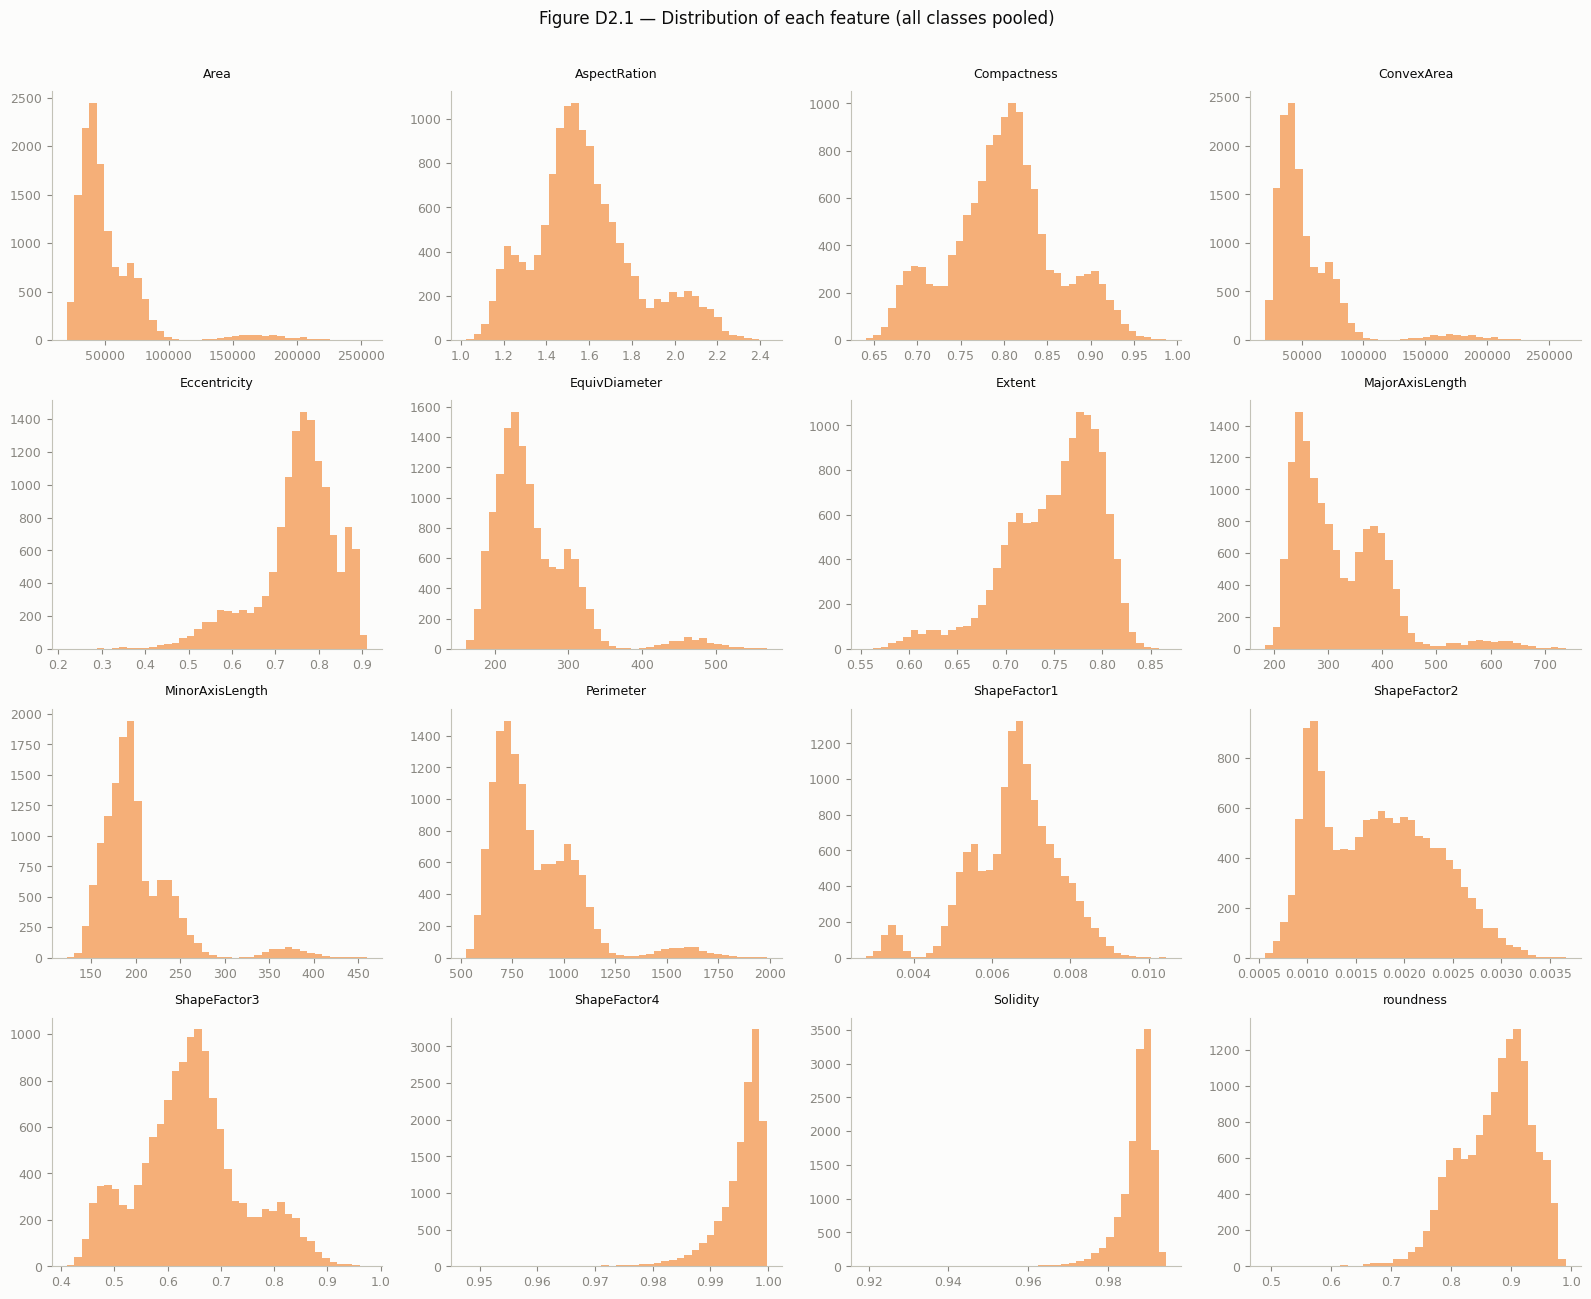

In [13]:
# Fig D2.1 Overall distribution of every feature (all classes pooled)

n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    ax.hist(df[col], bins=40, color="#f4a261", alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
for j in range(n_features, len(axes)):
    axes[j].axis('off')

fig.suptitle("Figure D2.1 — Distribution of each feature (all classes pooled)", y=1.01, fontsize=12)
plt.tight_layout()
savefig("figD2_1_feature_histograms_overall.png")
plt.show()

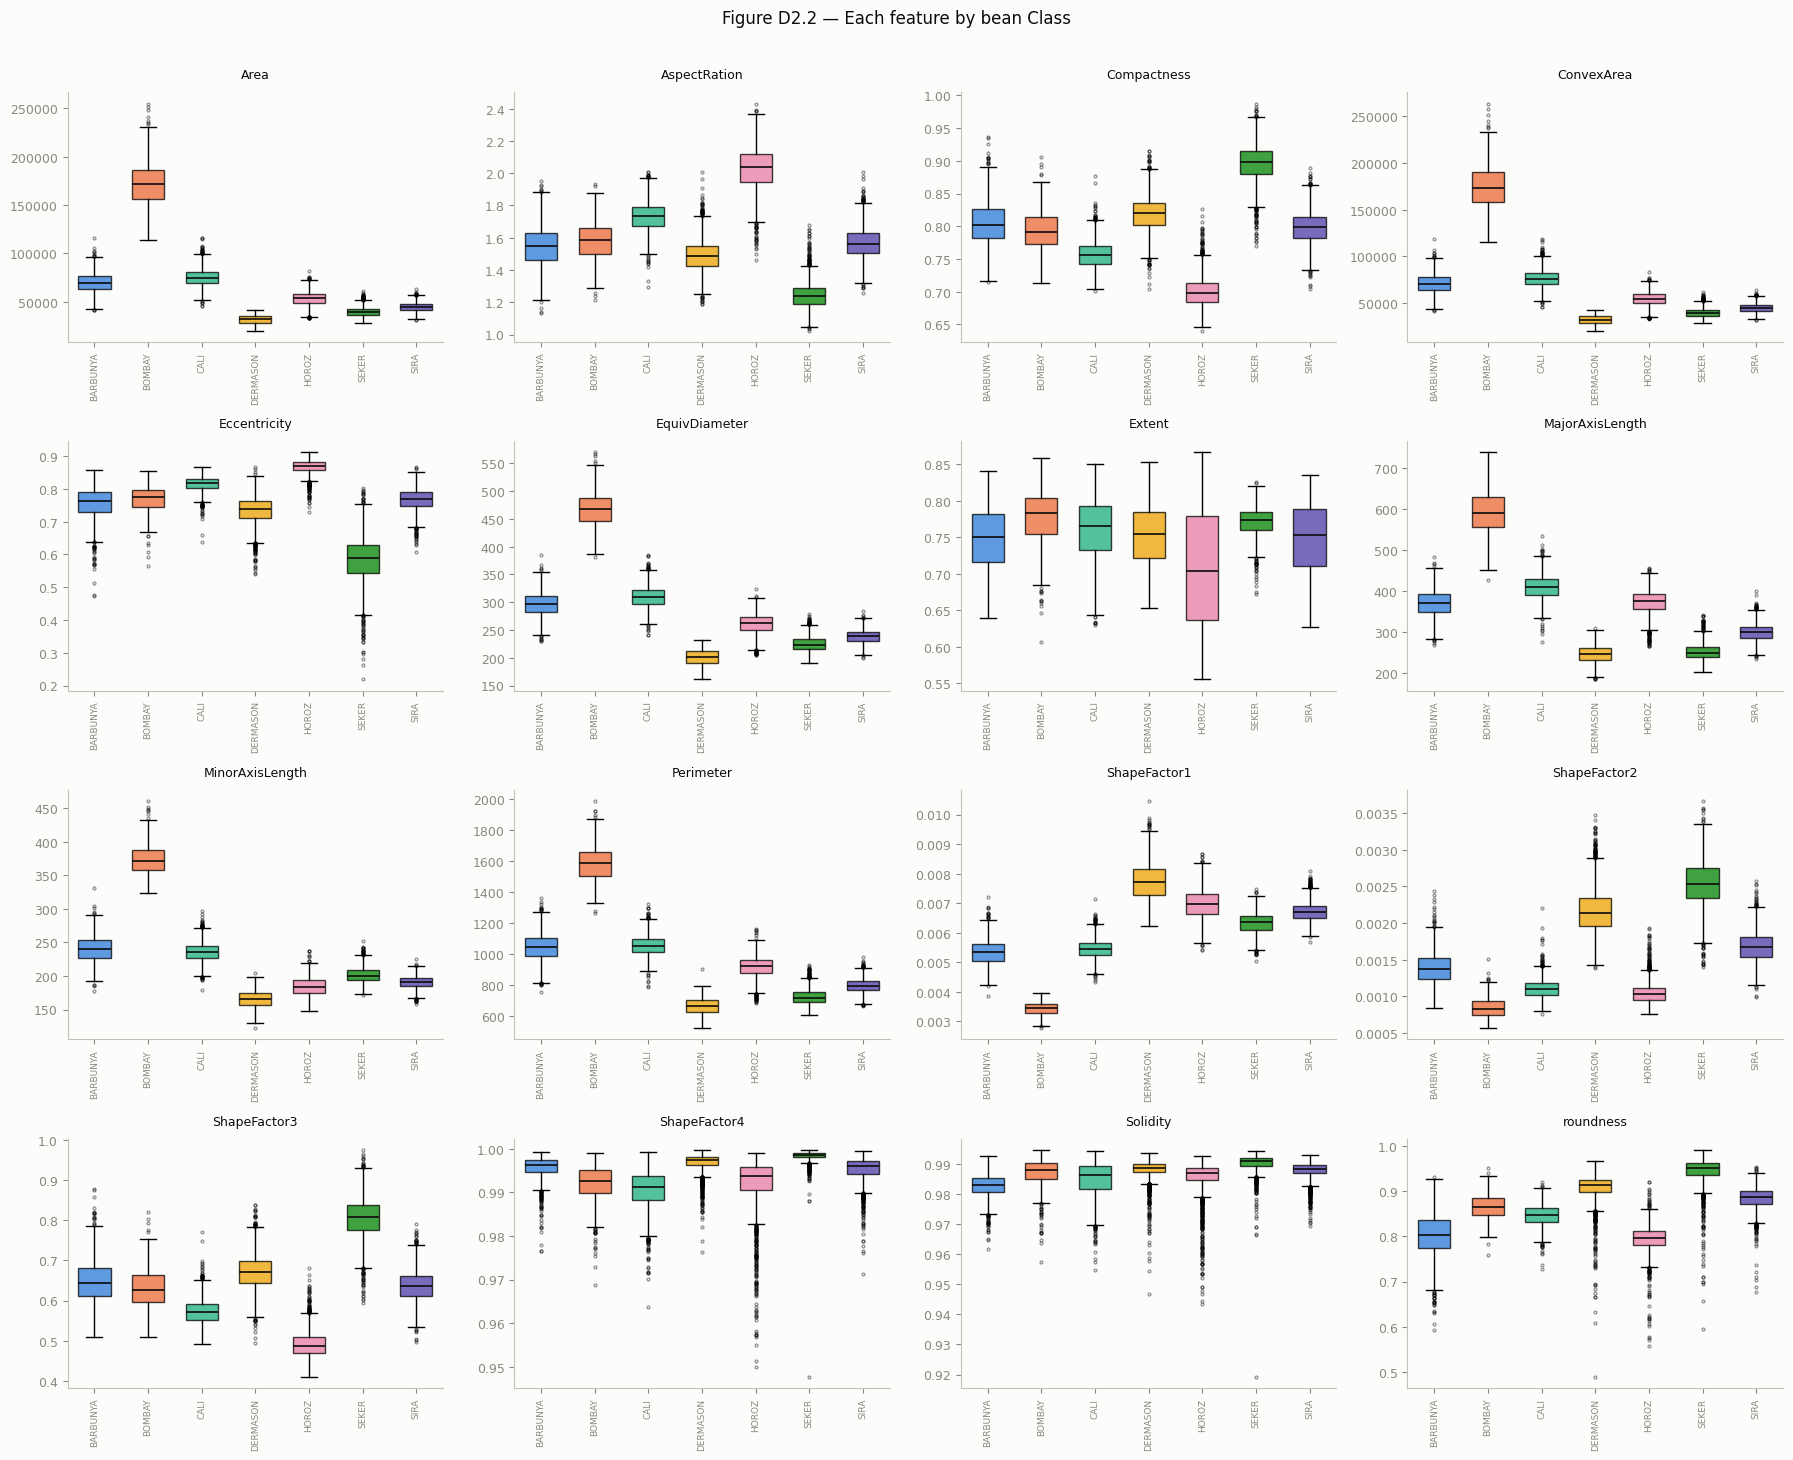

In [14]:
# Fig D2.2. Distribution of every feature, split by Class (boxplots)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.6 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    box_data = [df.loc[df['Class'] == c, col] for c in CLASS_ORDER]
    bp = ax.boxplot(box_data, patch_artist=True, widths=0.6, showfliers=True,
                     medianprops=dict(color=TEXT_PRIMARY, linewidth=1.2),
                     flierprops=dict(markersize=2, alpha=0.4))
    for patch, c in zip(bp['boxes'], CLASS_ORDER):
        patch.set_facecolor(CLASS_COLORS[c])
        patch.set_alpha(0.75)
    ax.set_xticklabels(CLASS_ORDER, rotation=90, fontsize=6.5)
    ax.set_title(col, fontsize=9)
for j in range(n_features, len(axes)):
    axes[j].axis('off')

fig.suptitle("Figure D2.2 — Each feature by bean Class", y=1.01, fontsize=12)
plt.tight_layout()
savefig("figD2_2_feature_boxplots_by_class.png")
plt.show()

In [15]:
# Per-feature, per-class summary statistics (saved for report Appendix)

summary_rows = []
for col in feature_cols:
    for c in CLASS_ORDER:
        vals = df.loc[df['Class'] == c, col]
        summary_rows.append({
            'feature': col, 'class': c, 'n': len(vals),
            'mean': vals.mean(), 'std': vals.std(),
            'min': vals.min(), 'median': vals.median(), 'max': vals.max(),
        })
class_feature_summary = pd.DataFrame(summary_rows)
print(class_feature_summary.round(3).to_string(index=False))

summary_csv_path = os.path.join(OUTPUT_DIR, '..', 'tableD2_1_feature_by_class_summary.csv')
class_feature_summary.round(4).to_csv(summary_csv_path, index=False)
print(f"\nSaved per-feature/per-class summary table to: {summary_csv_path}")



        feature    class    n       mean       std        min     median        max
           Area BARBUNYA 1322  69804.133 10265.386  41487.000  69582.000 115967.000
           Area   BOMBAY  522 173485.059 23327.688 114004.000 171494.500 254616.000
           Area     CALI 1630  75538.211  9379.881  45504.000  74791.500 116272.000
           Area DERMASON 3546  32118.711  4676.129  20420.000  31890.000  42159.000
           Area    HOROZ 1928  53648.509  7341.398  33006.000  53800.500  81929.000
           Area    SEKER 2027  39881.300  4779.877  28395.000  39180.000  61150.000
           Area     SIRA 2636  44729.129  4546.770  31519.000  44593.000  63612.000
   AspectRation BARBUNYA 1322      1.544     0.126      1.136      1.548      1.950
   AspectRation   BOMBAY  522      1.586     0.119      1.213      1.586      1.934
   AspectRation     CALI 1630      1.734     0.092      1.297      1.734      2.008
   AspectRation DERMASON 3546      1.490     0.096      1.188      1.485    

In [16]:
# Skewness check -- flags features that may need a transform in Data Prep

skew_summary = df[feature_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)
print("Skewness by feature (sorted by |skew|, pooled across all classes):")
print(skew_summary.round(3))

highly_skewed = skew_summary[skew_summary.abs() > 1]
print(f"\nFeatures with |skew| > 1 ({len(highly_skewed)} of {n_features}) -- "
      f"candidates for a log/Box-Cox transform in Data Preparation (Day 4):")
print(highly_skewed.round(3) if len(highly_skewed) else "  None.")

Skewness by feature (sorted by |skew|, pooled across all classes):
Area               2.953
ConvexArea         2.942
ShapeFactor4      -2.759
Solidity          -2.550
MinorAxisLength    2.238
EquivDiameter      1.949
Perimeter          1.626
MajorAxisLength    1.358
Eccentricity      -1.063
Extent            -0.895
roundness         -0.636
AspectRation       0.583
ShapeFactor1      -0.534
ShapeFactor2       0.301
ShapeFactor3       0.242
Compactness        0.037
dtype: float64

Features with |skew| > 1 (9 of 16) -- candidates for a log/Box-Cox transform in Data Preparation (Day 4):
Area               2.953
ConvexArea         2.942
ShapeFactor4      -2.759
Solidity          -2.550
MinorAxisLength    2.238
EquivDiameter      1.949
Perimeter          1.626
MajorAxisLength    1.358
Eccentricity      -1.063
dtype: float64


In [17]:
# =========================================================
# Per-feature separability ranking (between/within-class variance ratio)
# =========================================================
separability = {}
for col in feature_cols:
    grand_mean = df[col].mean()
    between = sum(len(df[df['Class'] == c]) * (df.loc[df['Class'] == c, col].mean() - grand_mean) ** 2
                  for c in CLASS_ORDER)
    within = sum(((df.loc[df['Class'] == c, col] - df.loc[df['Class'] == c, col].mean()) ** 2).sum()
                 for c in CLASS_ORDER)
    separability[col] = between / within if within > 0 else np.nan

sep_series = pd.Series(separability).sort_values(ascending=False)
print("Features ranked by between/within-class variance ratio (higher = more separating power):")
print(sep_series.round(3))
print(f"\nMost separating feature: {sep_series.index[0]} (ratio={sep_series.iloc[0]:.3f})")
print(f"Least separating feature: {sep_series.index[-1]} (ratio={sep_series.iloc[-1]:.3f})")

Features ranked by between/within-class variance ratio (higher = more separating power):
Area               12.798
ConvexArea         12.774
EquivDiameter      11.222
Perimeter          10.710
MinorAxisLength     9.898
MajorAxisLength     9.536
ShapeFactor2        5.438
ShapeFactor1        5.328
AspectRation        4.577
Compactness         4.484
ShapeFactor3        4.367
Eccentricity        3.650
roundness           2.715
ShapeFactor4        0.554
Solidity            0.279
Extent              0.186
dtype: float64

Most separating feature: Area (ratio=12.798)
Least separating feature: Extent (ratio=0.186)


In [18]:
# Fig D2.3 Pick 2 separating, non-redundant variables and plot them


SIZE_CLUSTER = {'Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter'}
corr_all = df[feature_cols].corr().abs()

var1 = sep_series.index[0]
var1_is_size = var1 in SIZE_CLUSTER

var2 = None
for candidate in sep_series.index[1:]:
    if corr_all.loc[var1, candidate] >= 0.9:
        continue                                   # redundant with var1
    if var1_is_size and candidate in SIZE_CLUSTER:
        continue                                   # both from the size cluster -- same axis of variation
    var2 = candidate
    break

print(f"Selected pair: {var1} (rank 1, ratio={sep_series[var1]:.3f}) "
      f"and {var2} (ratio={sep_series[var2]:.3f}), "
      f"correlation r={df[var1].corr(df[var2]):.3f}")
print(f"(Domain hypothesis was Perimeter x AspectRation; "
      f"{'confirmed by the ranking' if {var1, var2} == {'Perimeter', 'AspectRation'} else 'the data-driven pick differs -- see ratios above'})")

Selected pair: Area (rank 1, ratio=12.798) and ShapeFactor2 (ratio=5.438), correlation r=-0.639
(Domain hypothesis was Perimeter x AspectRation; the data-driven pick differs -- see ratios above)


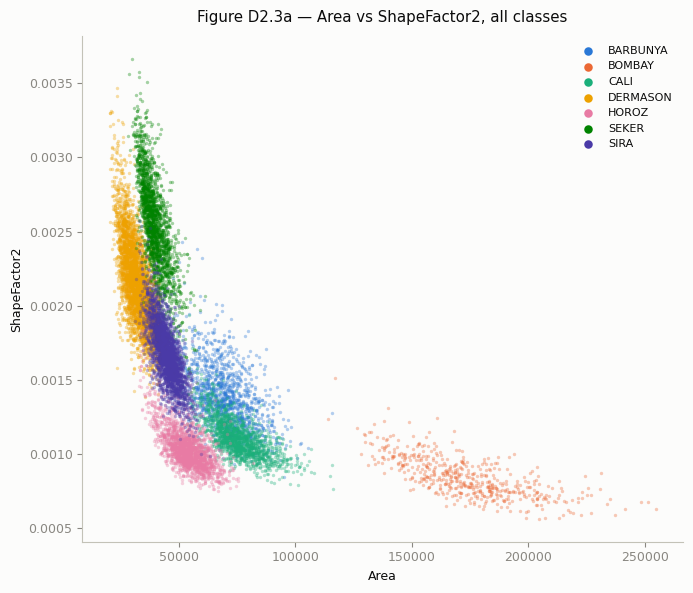

In [19]:
# Fig D2.3a Combined scatter, all 7 classes at once (quick overview)

fig, ax = plt.subplots(figsize=(7, 6))
for c in CLASS_ORDER:
    subset = df[df['Class'] == c]
    ax.scatter(subset[var1], subset[var2], s=6, alpha=0.35, linewidths=0,
               color=CLASS_COLORS[c], label=c)
ax.set_xlabel(var1)
ax.set_ylabel(var2)
ax.set_title(f"Figure D2.3a — {var1} vs {var2}, all classes")
leg = ax.legend(frameon=False, markerscale=2.5, loc='best', fontsize=8)
for lh in leg.legend_handles:
    lh.set_alpha(1)
plt.tight_layout()
savefig("figD2_3a_separability_scatter_combined.png")
plt.show()


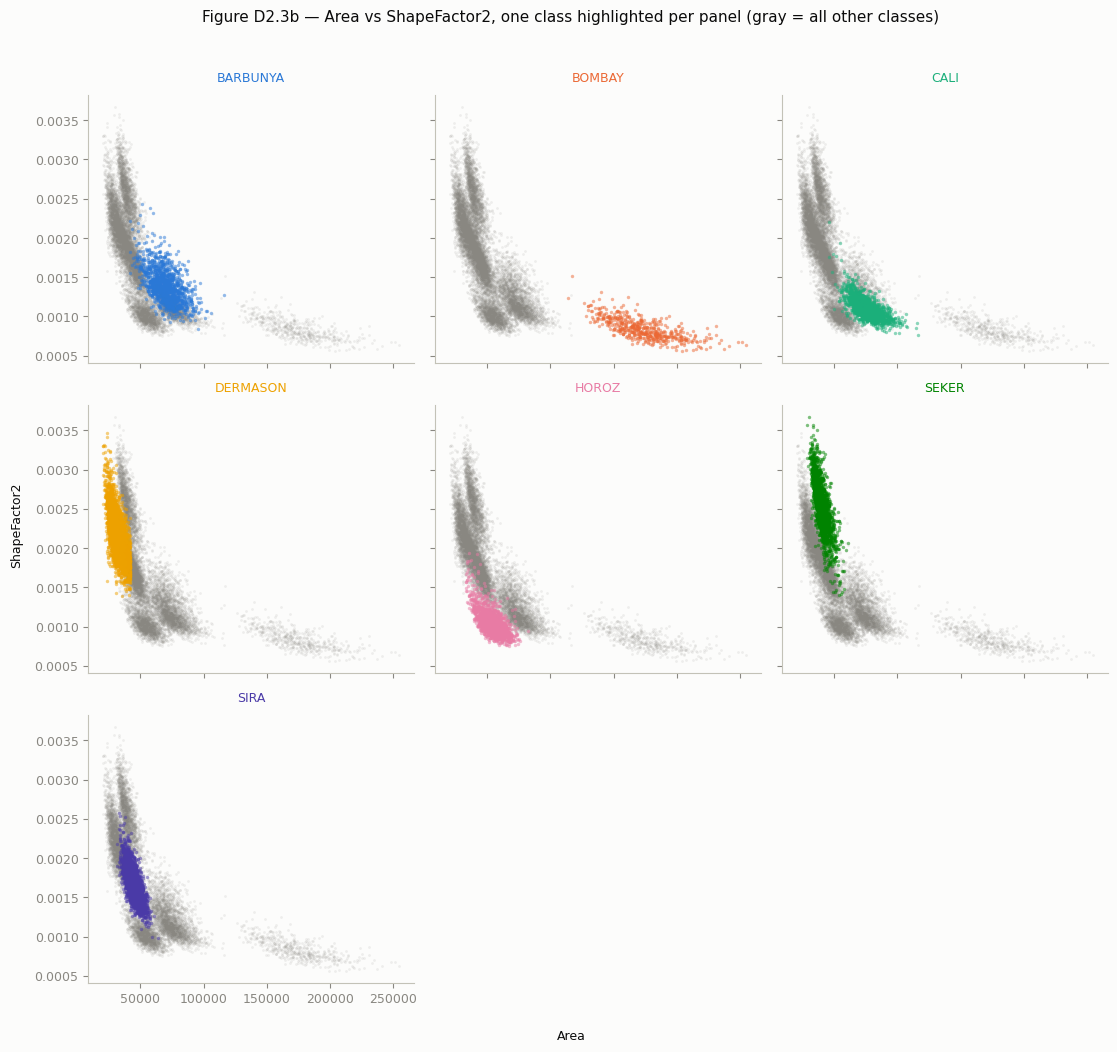

In [20]:
# Fig D2.3b -- Same 2 variables, small multiples (one class highlighted each)

n_classes = len(CLASS_ORDER)
grid_cols = 3
grid_rows = int(np.ceil(n_classes / grid_cols))
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(11, 3.3 * grid_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, c in enumerate(CLASS_ORDER):
    ax = axes[i]
    background = df[df['Class'] != c]
    highlight = df[df['Class'] == c]
    ax.scatter(background[var1], background[var2], s=4, alpha=0.12,
               color=TEXT_MUTED, linewidths=0)
    ax.scatter(highlight[var1], highlight[var2], s=6, alpha=0.5, linewidths=0,
               color=CLASS_COLORS[c])
    ax.set_title(c, fontsize=9, color=CLASS_COLORS[c])
for j in range(n_classes, len(axes)):
    axes[j].axis('off')
fig.suptitle(f"Figure D2.3b — {var1} vs {var2}, one class highlighted per panel "
             f"(gray = all other classes)", y=1.02, fontsize=11)
fig.text(0.5, -0.02, var1, ha='center', fontsize=9)
fig.text(-0.01, 0.5, var2, va='center', rotation='vertical', fontsize=9)
plt.tight_layout()
savefig("figD2_3b_separability_scatter_small_multiples.png")
plt.show()


In [21]:
# Univariate EDA summary / working notes for the group

print("=" * 70)
print("DAY 2 UNIVARIATE EDA SUMMARY -- Dry Bean Dataset")
print("=" * 70)
print(f"Features examined: {n_features}")
print(f"Classes: {CLASS_ORDER}")
print(f"Most right/left-skewed feature: {skew_summary.index[0]} (skew={skew_summary.iloc[0]:.2f})")
print(f"Features with |skew| > 1: {len(highly_skewed)}")
print(f"Most separating single feature: {sep_series.index[0]} (ratio={sep_series.iloc[0]:.3f})")
print(f"Least separating single feature: {sep_series.index[-1]} (ratio={sep_series.iloc[-1]:.3f})")
print(f"2-variable separability view: {var1} x {var2} (Figures D2.3a/b)")


DAY 2 UNIVARIATE EDA SUMMARY -- Dry Bean Dataset
Features examined: 16
Classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Most right/left-skewed feature: Area (skew=2.95)
Features with |skew| > 1: 9
Most separating single feature: Area (ratio=12.798)
Least separating single feature: Extent (ratio=0.186)
2-variable separability view: Area x ShapeFactor2 (Figures D2.3a/b)


# Dry Bean EDA: Key Insights

## BOMBAY separates almost by itself

Area is the single strongest separating feature (ratio 12.80, more than 2x the runner-up). BOMBAY's mean Area (173,485) is over double the next-largest class (CALI, 75,538) and nearly 5x the smallest (DERMASON, 32,119). The same holds for Perimeter, ConvexArea, EquivDiameter, and both axis lengths. In the Figure D2.3a scatter, BOMBAY forms a visually isolated cluster with almost no overlap. This class needs no clever feature engineering to detect, just size.

## SEKER and HOROZ are the shape extremes

Across every scale-invariant shape feature, SEKER and HOROZ sit at opposite ends: Eccentricity (SEKER 0.585 vs. HOROZ 0.867), AspectRation (SEKER 1.245 vs. HOROZ 2.026), Compactness (SEKER 0.897 vs. HOROZ 0.701), roundness (SEKER 0.945 vs. HOROZ 0.794), ShapeFactor3 (SEKER 0.805 vs. HOROZ 0.492). This lines up with the bean names: HOROZ ("rooster bean") is the most elongated variety, SEKER ("sugar bean") the most round, the shape features are measuring exactly what the earlier reference photos suggested.

## The middle 5 classes overlap heavily on size and shape alone

Excluding BOMBAY, BARBUNYA, CALI, DERMASON, SEKER, and SIRA span overlapping Area ranges (roughly 32k–76k) and overlapping AspectRation/Compactness bands. SIRA in particular sits in the middle of nearly every feature's distribution,  it's the hardest single class to isolate with any one or two variables. Extent is the weakest single separator of all 16 features (ratio 0.186); all seven classes cluster tightly between 0.71–0.78 on it.

## Area x ShapeFactor2 (Figure D2.3a/b): confirms the pattern, doesn't fully resolve it

The automatic 2-variable pick (top-ranked Area + next-best non-redundant ShapeFactor2, r = -0.639) visually confirms both findings above: BOMBAY splits off completely, and SEKER/DERMASON separate from HOROZ along the ShapeFactor2 axis even where their Area ranges overlap. But BARBUNYA, CALI, and SIRA still overlap substantially in this 2D view, full 7-class separation will need more than two features, which is expected and simply confirms the value of a multivariate model over any 2D projection.

## Skewness (9 of 16 features, |skew| > 1) has an identifiable cause, not just noise

All the positively-skewed features (Area, ConvexArea, MinorAxisLength, EquivDiameter, Perimeter, MajorAxisLength, skew 1.36 to 2.95) are size measurements, and the skew is very likely driven by BOMBAY sitting far out on the right tail as its own distinct subpopulation, not by noisy within-class distributions. The negatively-skewed features (ShapeFactor4, Solidity, Eccentricity) are bounded ratios pulled left mainly by SEKER's much lower Eccentricity (mean 0.585, min 0.219) relative to the other six classes.

## What this means for Data Preparation

- A log or Box-Cox transform on the skewed size features should be evaluated per-model (helps Logistic Regression, unnecessary for tree-based models), but note the skew is class-structure, not univariate noise, transforming won't "fix" BOMBAY's separation, it's already trivially separable.
- Shape features (AspectRation, Eccentricity, Compactness, roundness, ShapeFactor3) carry real, non-redundant discriminative power beyond size and should not be dropped even after addressing size-feature multicollinearity (Day 2 audit finding), they're what separates SEKER from HOROZ and could help pull SIRA/BARBUNYA/CALI apart.
- No 2-variable view fully separates all 7 classes, which is expected and simply reinforces that Modeling (not manual 2D feature selection) is where the harder classes will actually get resolved, useful context to include in Data Understanding when justifying the modeling approach.


In [22]:
# DATA PREPARATION

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# TODO: replace with whatever seed the team actually agreed on at kickoff

RANDOM_SEED = 42

ALL_16_FEATURES = df.columns.difference(['Class']).tolist()
print("Starting from raw df:", df.shape)

Starting from raw df: (13611, 17)


In [23]:
# 4.1 Remove exact duplicate rows (flagged in the Day 2 audit)

n_before = len(df)
df_clean = df.drop_duplicates().reset_index(drop=True)
n_after = len(df_clean)
print(f"Dropped {n_before - n_after} duplicate rows ({n_before} -> {n_after})")

Dropped 68 duplicate rows (13611 -> 13543)


In [24]:
# 4.2 Missing / invalid values

missing = df_clean[ALL_16_FEATURES].isnull().sum()
print("Missing values in df_clean:\n", missing[missing > 0] if missing.any() else "None found.")

Missing values in df_clean:
 None found.


In [25]:
# 4.3 Categorical variable treatment
# Not applicable: every one of the 16 original features is a continuous
# geometric measurement (see Day 2 audit, section 2.7 -- no categorical
# predictors, no identifier columns in this dataset). No encoding step is
# needed on the feature side.

In [26]:
# 4.4 Target encoding

label_encoder = LabelEncoder()
df_clean['Class_encoded'] = label_encoder.fit_transform(df_clean['Class'])

print("Class label encoding:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} -> {cls}")

Class label encoding:
  0 -> BARBUNYA
  1 -> BOMBAY
  2 -> CALI
  3 -> DERMASON
  4 -> HOROZ
  5 -> SEKER
  6 -> SIRA


In [27]:
# 4.5 Train/test split -- BEFORE feature selection, so VIF never sees test rows

X_full = df_clean[ALL_16_FEATURES]
y = df_clean['Class']                          # string labels -- human-readable output
y_encoded = df_clean['Class_encoded']          # integer labels -- for libraries that require them (e.g. XGBoost)

X_train_full, X_test_full, y_train, y_test, y_train_encoded, y_test_encoded = train_test_split(
    X_full, y, y_encoded, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

print("Train shape (all 16 features):", X_train_full.shape, "| Test shape:", X_test_full.shape)

Train shape (all 16 features): (10834, 16) | Test shape: (2709, 16)


In [28]:
# 4.6 Multicollinearity: iterative VIF-based feature selection

VIF_THRESHOLD = 10.0

def compute_vif(X):
    """VIF for every column in X, against all the OTHER columns in X.
    Near-perfectly collinear columns (e.g. Area vs. ConvexArea, r~1.0) make
    the design matrix singular/poorly conditioned -- statsmodels warns about
    this but still returns a valid (very large, effectively infinite) VIF,
    which is exactly the correct signal to eliminate that column next, so
    the expected warning is suppressed here rather than silencing anything
    that changes the result."""
    X_with_const = sm.add_constant(X)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        vifs = pd.Series(
            [variance_inflation_factor(X_with_const.values, i)
             for i in range(1, X_with_const.shape[1])],
            index=X.columns,
        )
    return vifs.sort_values(ascending=False)


print("VIF for all 16 features (X_train_full), before any removal:")
print(compute_vif(X_train_full).round(2))

X_vif_working = X_train_full.copy()
elimination_log = []
while True:
    vifs = compute_vif(X_vif_working)
    worst_feature, worst_vif = vifs.index[0], vifs.iloc[0]
    if worst_vif <= VIF_THRESHOLD or X_vif_working.shape[1] <= 1:
        break
    elimination_log.append((worst_feature, worst_vif))
    X_vif_working = X_vif_working.drop(columns=[worst_feature])

FEATURE_COLS = X_vif_working.columns.tolist()

print(f"\nIterative elimination log (threshold VIF > {VIF_THRESHOLD}):")
for feature, vif in elimination_log:
    print(f"  Dropped {feature:<20s} (VIF = {vif:,.2f} at time of removal)")
print(f"\nDropped {len(elimination_log)} feature(s): {[f for f, _ in elimination_log]}")
print(f"Retained {len(FEATURE_COLS)} predictors: {FEATURE_COLS}")
print("\nFinal VIF for retained features (all should now be <= threshold):")
print(compute_vif(X_vif_working).round(2))

VIF for all 16 features (X_train_full), before any removal:
EquivDiameter      312244.60
Compactness        270180.86
ShapeFactor3       195723.97
MajorAxisLength     87007.78
Area                85873.52
ConvexArea          83475.78
MinorAxisLength     76592.43
AspectRation        13518.12
Perimeter            3834.85
ShapeFactor2         1232.68
Eccentricity         1154.45
ShapeFactor1          605.94
roundness             108.68
ShapeFactor4           65.88
Solidity               14.41
Extent                  1.23
dtype: float64

Iterative elimination log (threshold VIF > 10.0):
  Dropped EquivDiameter        (VIF = 312,244.60 at time of removal)
  Dropped Compactness          (VIF = 265,714.05 at time of removal)
  Dropped Area                 (VIF = 57,561.26 at time of removal)
  Dropped MajorAxisLength      (VIF = 4,443.06 at time of removal)
  Dropped Perimeter            (VIF = 1,929.91 at time of removal)
  Dropped ShapeFactor3         (VIF = 1,169.82 at time of removal)
  D

In [29]:
# 4.7 Apply the VIF-selected feature list everywhere
X_train = X_train_full[FEATURE_COLS]
X_test = X_test_full[FEATURE_COLS]

df_model = df_clean[FEATURE_COLS + ['Class', 'Class_encoded']].copy()
print("Cleaned/transformed dataset shape (VIF-selected features + target):", df_model.shape)

Cleaned/transformed dataset shape (VIF-selected features + target): (13543, 9)


In [30]:
df_model.head()


,ConvexArea,Eccentricity,Extent,ShapeFactor1,ShapeFactor4,Solidity,roundness,Class,Class_encoded
0,28715,0.549812,0.763923,0.007332,0.998724,0.988856,0.958027,SEKER,5
1,29172,0.411785,0.783968,0.006979,0.998430,0.984986,0.887034,SEKER,5
2,29690,0.562727,0.778113,0.007244,0.999066,0.989559,0.947849,SEKER,5
3,30724,0.498616,0.782681,0.007017,0.994199,0.976696,0.903936,SEKER,5
4,30417,0.333680,0.773098,0.006697,0.999166,0.990893,0.984877,SEKER,5


In [31]:
# 4.8 Save the cleaned and transformed dataset (Deliverable #3)

CLEANED_CSV_PATH = '/content/drive/MyDrive/DAMO510 Final Project/DAMO510_FinalProject_TeamJMV_Dataset_Cleaned.csv'
df_model.to_csv(CLEANED_CSV_PATH, index=False)
print(f"Saved cleaned/transformed dataset ({df_model.shape[0]} rows x {df_model.shape[1]} cols) to:\n  {CLEANED_CSV_PATH}")

Saved cleaned/transformed dataset (13543 rows x 9 cols) to:
  /content/drive/MyDrive/DAMO510 Final Project/DAMO510_FinalProject_TeamJMV_Dataset_Cleaned.csv


In [32]:
# 4.9 Scaling decisions (MODEL-DEPENDENT preprocessing)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLS, index=X_test.index)

print("StandardScaler mean_ (from X_train only):\n", pd.Series(scaler.mean_, index=FEATURE_COLS).round(3))
print("\nUsage going forward:")
print("  Logistic Regression        -> X_train_scaled / X_test_scaled")
print("  Random Forest, XGBoost     -> X_train / X_test (raw, unscaled)")

StandardScaler mean_ (from X_train only):
 ConvexArea      53736.120
Eccentricity        0.750
Extent              0.750
ShapeFactor1        0.007
ShapeFactor4        0.995
Solidity            0.987
roundness           0.874
dtype: float64

Usage going forward:
  Logistic Regression        -> X_train_scaled / X_test_scaled
  Random Forest, XGBoost     -> X_train / X_test (raw, unscaled)


In [33]:
# 4.10 Class imbalance, staged, not yet intervened on

print("Class balance preserved by the stratified split:")
print("  y_train:\n", (y_train.value_counts(normalize=True) * 100).round(2))
print("  y_test:\n", (y_test.value_counts(normalize=True) * 100).round(2))

Class balance preserved by the stratified split:
  y_train:
 Class
DERMASON    26.19
SIRA        19.47
SEKER       14.96
HOROZ       13.73
CALI        12.04
BARBUNYA     9.76
BOMBAY       3.86
Name: proportion, dtype: float64
  y_test:
 Class
DERMASON    26.17
SIRA        19.45
SEKER       14.99
HOROZ       13.73
CALI        12.03
BARBUNYA     9.78
BOMBAY       3.84
Name: proportion, dtype: float64


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc,
)

print("Test set size:", len(y_test))
print("Test set class distribution (%):\n", (y_test.value_counts(normalize=True) * 100).round(2))

Test set size: 2709
Test set class distribution (%):
 Class
DERMASON    26.17
SIRA        19.45
SEKER       14.99
HOROZ       13.73
CALI        12.03
BARBUNYA     9.78
BOMBAY       3.84
Name: proportion, dtype: float64


In [35]:
#  5.1 Evaluation helper -- the SAME metric set every later model is judged on

def evaluate_baseline(clf, X_train, X_test, y_train, y_test, name):
    """Fit a baseline classifier and report accuracy plus BOTH macro- and
    weighted-averaged precision/recall/F1 -- macro treats all 7 classes
    equally (what matters given the class imbalance the Day 2 audit
    confirmed), weighted reflects the actual class sizes. Also reports
    macro one-vs-rest ROC-AUC and per-class recall, since accuracy alone
    cannot reveal whether a baseline is silently failing the minority
    classes (BOMBAY, BARBUNYA)."""
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    y_test_bin = label_binarize(y_test, classes=CLASS_ORDER)
    # Align predict_proba's column order with CLASS_ORDER (DummyClassifier
    # orders classes_ alphabetically, which happens to match CLASS_ORDER here,
    # but this reindex makes that assumption explicit rather than silent).
    proba_df = pd.DataFrame(y_proba, columns=clf.classes_)[CLASS_ORDER].values
    auc_macro = roc_auc_score(y_test_bin, proba_df, average='macro', multi_class='ovr')

    cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
    per_class_recall = pd.Series(np.diag(cm) / cm.sum(axis=1), index=CLASS_ORDER)

    print(f"\n{'=' * 65}")
    print(name)
    print("=" * 65)
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (macro):   {prec_macro:.4f}   | (weighted): {prec_weighted:.4f}")
    print(f"Recall (macro):      {rec_macro:.4f}   | (weighted): {rec_weighted:.4f}")
    print(f"F1-score (macro):    {f1_macro:.4f}   | (weighted): {f1_weighted:.4f}")
    print(f"ROC-AUC (macro OvR): {auc_macro:.4f}")
    print("\nPer-class recall:")
    print(per_class_recall.round(4))

    return {'name': name, 'accuracy': acc, 'precision_macro': prec_macro,
            'recall_macro': rec_macro, 'f1_macro': f1_macro,
            'precision_weighted': prec_weighted, 'recall_weighted': rec_weighted,
            'f1_weighted': f1_weighted, 'roc_auc_macro_ovr': auc_macro,
            'confusion_matrix': cm, 'per_class_recall': per_class_recall}


In [36]:
# 5.2 Baseline A Majority-class ("always predict DERMASON")
majority_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
majority_results = evaluate_baseline(
    majority_clf, X_train, X_test, y_train, y_test,
    "Baseline A: Majority-class (always predicts 'DERMASON')"
)


Baseline A: Majority-class (always predicts 'DERMASON')
Accuracy:            0.2617
Precision (macro):   0.0374   | (weighted): 0.0685
Recall (macro):      0.1429   | (weighted): 0.2617
F1-score (macro):    0.0593   | (weighted): 0.1086
ROC-AUC (macro OvR): 0.5000

Per-class recall:
BARBUNYA    0.0
BOMBAY      0.0
CALI        0.0
DERMASON    1.0
HOROZ       0.0
SEKER       0.0
SIRA        0.0
dtype: float64


In [37]:
# 5.3 Baseline B Stratified random (prior-weighted guessing)
stratified_clf = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
stratified_results = evaluate_baseline(
    stratified_clf, X_train, X_test, y_train, y_test,
    "Baseline B: Stratified random (base-rate-weighted guessing)"
)


Baseline B: Stratified random (base-rate-weighted guessing)
Accuracy:            0.1694
Precision (macro):   0.1420   | (weighted): 0.1687
Recall (macro):      0.1418   | (weighted): 0.1694
F1-score (macro):    0.1418   | (weighted): 0.1690
ROC-AUC (macro OvR): 0.4991

Per-class recall:
BARBUNYA    0.1094
BOMBAY      0.0481
CALI        0.0982
DERMASON    0.2482
HOROZ       0.1452
SEKER       0.1502
SIRA        0.1935
dtype: float64


In [38]:
# 5.4 Side-by-side summary
summary_cols = ['name', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
                 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc_macro_ovr']
summary = pd.DataFrame([majority_results, stratified_results])[summary_cols]
print("\n" + "=" * 65)
print("Baseline comparison")
print("=" * 65)
print(summary.round(4).to_string(index=False))

print("\nWhat this baseline demonstrates about problem difficulty:")
print(f"  - A trivial 'always guess the largest class' rule already reaches "
      f"{majority_results['accuracy']*100:.1f}% accuracy purely from class sizes, "
      f"not from anything learned about bean shape.")
print(f"  - Its macro recall ({majority_results['recall_macro']:.4f}) and macro F1 "
      f"({majority_results['f1_macro']:.4f}) collapse toward 1/7, exposing that it is "
      f"blind to 6 of the 7 varieties -- the real bar any model in this project must clear "
      f"is macro-averaged performance, not raw accuracy.")



Baseline comparison
                                                       name  accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  recall_weighted  f1_weighted  roc_auc_macro_ovr
    Baseline A: Majority-class (always predicts 'DERMASON')    0.2617           0.0374        0.1429    0.0593              0.0685           0.2617       0.1086             0.5000
Baseline B: Stratified random (base-rate-weighted guessing)    0.1694           0.1420        0.1418    0.1418              0.1687           0.1694       0.1690             0.4991

What this baseline demonstrates about problem difficulty:
  - A trivial 'always guess the largest class' rule already reaches 26.2% accuracy purely from class sizes, not from anything learned about bean shape.
  - Its macro recall (0.1429) and macro F1 (0.0593) collapse toward 1/7, exposing that it is blind to 6 of the 7 varieties -- the real bar any model in this project must clear is macro-averaged performance, not raw accuracy.


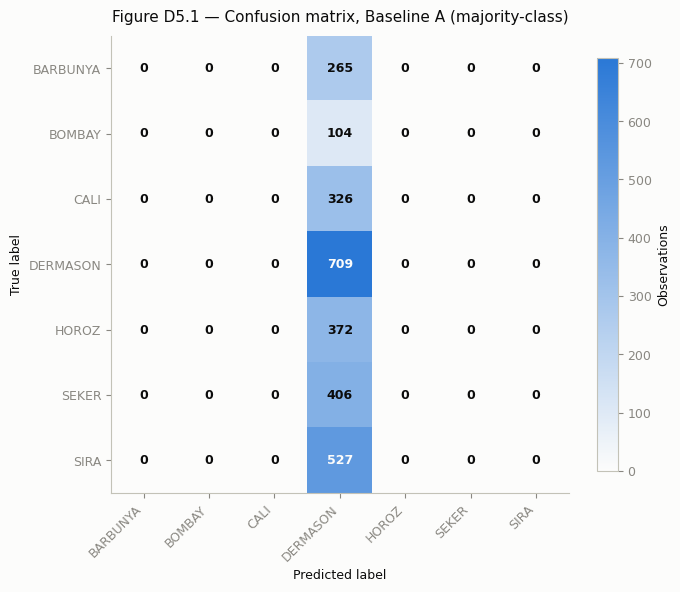

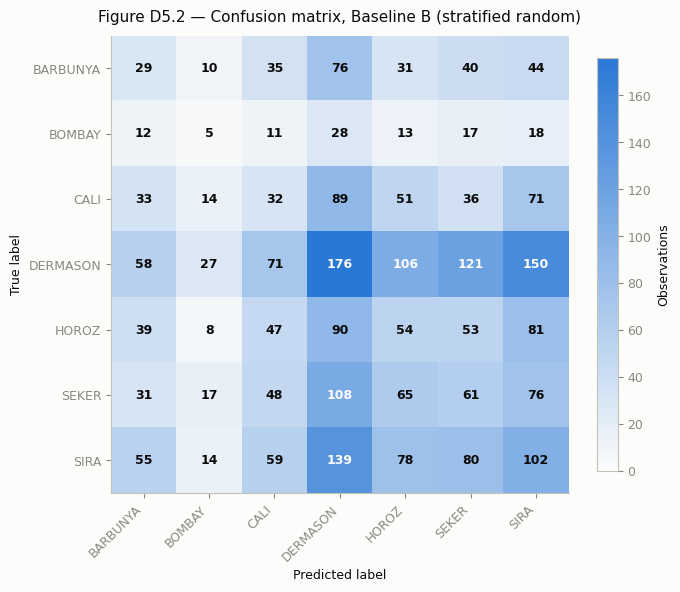

In [39]:
# 5.5 Visualizations: confusion matrices for both baselines

CONFUSION_CMAP = LinearSegmentedColormap.from_list(
    "blue_sequential", ["#fcfcfb", CLASS_COLORS['BARBUNYA']], N=256
)


def plot_confusion_matrix(cm, title, filename):
    """7x7 sequential-blue confusion matrix, annotated with counts.
    Rows = true label, columns = predicted label (CLASS_ORDER on both axes)."""
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap=CONFUSION_CMAP, vmin=0)
    ax.set_xticks(range(len(CLASS_ORDER))); ax.set_xticklabels(CLASS_ORDER, rotation=45, ha='right')
    ax.set_yticks(range(len(CLASS_ORDER))); ax.set_yticklabels(CLASS_ORDER)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title, fontsize=11)
    ax.grid(False)

    cell_max = cm.max() if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text_color = TEXT_PRIMARY if value < 0.6 * cell_max else "#fcfcfb"
            ax.text(j, i, f"{value:,}", ha='center', va='center',
                     fontsize=9, color=text_color, fontweight='bold')

    fig.colorbar(im, ax=ax, shrink=0.85, label="Observations")
    plt.tight_layout()
    savefig(filename)
    plt.show()


plot_confusion_matrix(
    majority_results['confusion_matrix'],
    "Figure D5.1 — Confusion matrix, Baseline A (majority-class)",
    "figD5_1_confusion_baseline_a.png",
)

plot_confusion_matrix(
    stratified_results['confusion_matrix'],
    "Figure D5.2 — Confusion matrix, Baseline B (stratified random)",
    "figD5_2_confusion_baseline_b.png",
)


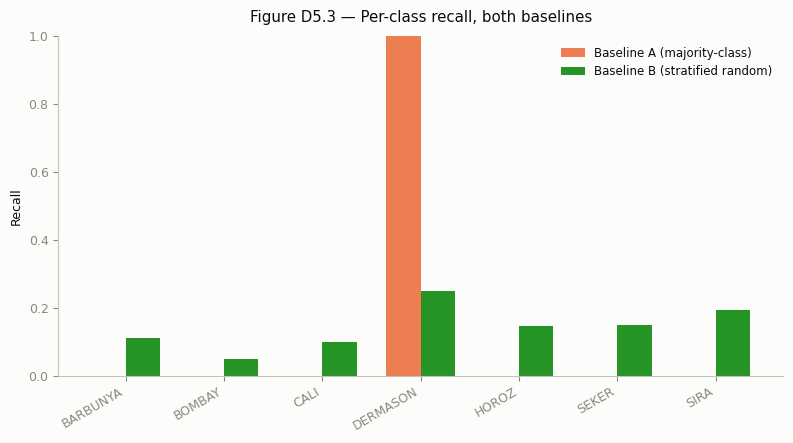

In [40]:
# 5.6 Per-class recall, both baselines side by side

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(CLASS_ORDER))
width = 0.35
ax.bar(x - width / 2, majority_results['per_class_recall'][CLASS_ORDER], width,
       label='Baseline A (majority-class)', color=CLASS_COLORS['BOMBAY'], alpha=0.85)
ax.bar(x + width / 2, stratified_results['per_class_recall'][CLASS_ORDER], width,
       label='Baseline B (stratified random)', color=CLASS_COLORS['SEKER'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha='right')
ax.set_ylabel("Recall")
ax.set_ylim(0, 1)
ax.set_title("Figure D5.3 — Per-class recall, both baselines")
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout()
savefig("figD5_3_per_class_recall_baselines.png")
plt.show()


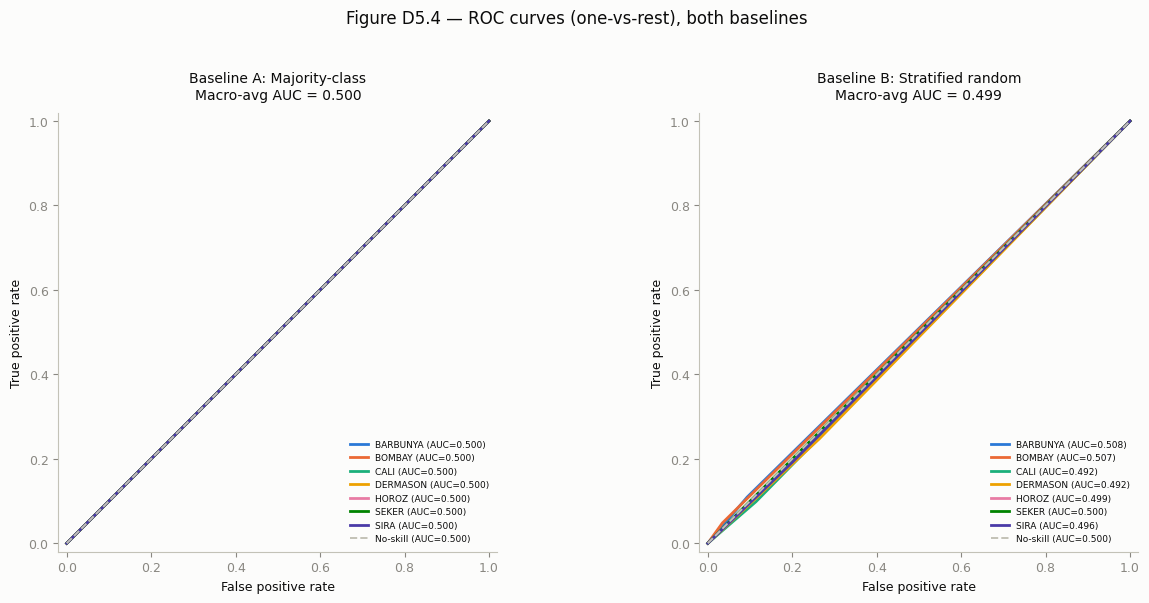

In [41]:
# 5.7 ROC curves (one-vs-rest), both baselines

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))

for ax, (clf, results, title) in zip(axes, [
    (majority_clf, majority_results, "Baseline A: Majority-class"),
    (stratified_clf, stratified_results, "Baseline B: Stratified random"),
]):
    proba_df = pd.DataFrame(clf.predict_proba(X_test), columns=clf.classes_)[CLASS_ORDER].values
    y_test_bin = label_binarize(y_test, classes=CLASS_ORDER)

    for c_idx, c in enumerate(CLASS_ORDER):
        fpr, tpr, _ = roc_curve(y_test_bin[:, c_idx], proba_df[:, c_idx])
        class_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=CLASS_COLORS[c], linewidth=2, label=f"{c} (AUC={class_auc:.3f})")

    ax.plot([0, 1], [0, 1], color=AXIS_COLOR, linestyle='--', linewidth=1.4,
            label="No-skill (AUC=0.500)")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{title}\nMacro-avg AUC = {results['roc_auc_macro_ovr']:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=6.5, loc='lower right')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')

fig.suptitle("Figure D5.4 — ROC curves (one-vs-rest), both baselines", y=1.03, fontsize=12)
plt.tight_layout()
savefig("figD5_4_roc_curves_baselines.png")
plt.show()


In [42]:
# Day 5 baseline summary / working notes for the group

print("=" * 65)
print("DAY 5 BASELINE SUMMARY -- Dry Bean Dataset")
print("=" * 65)
print(f"Baseline A (majority-class): accuracy={majority_results['accuracy']:.4f}, "
      f"macro F1={majority_results['f1_macro']:.4f}, "
      f"macro recall={majority_results['recall_macro']:.4f}")
print(f"Baseline B (stratified):     accuracy={stratified_results['accuracy']:.4f}, "
      f"macro F1={stratified_results['f1_macro']:.4f}, "
      f"macro recall={stratified_results['recall_macro']:.4f}")
print("\nEvery model from here on (Logistic Regression, Random Forest, XGBoost) "
      "must be judged primarily against macro F1 / macro recall, not raw accuracy -- "
      "a model that only learns to predict DERMASON well would still look "
      f"deceptively decent on accuracy alone ({majority_results['accuracy']*100:.0f}% floor).")
print("\nNext: Logistic Regression at default settings (Day 5 continued), "
      "then systematic tuning for Logistic Regression, Random Forest, and XGBoost.")

DAY 5 BASELINE SUMMARY -- Dry Bean Dataset
Baseline A (majority-class): accuracy=0.2617, macro F1=0.0593, macro recall=0.1429
Baseline B (stratified):     accuracy=0.1694, macro F1=0.1418, macro recall=0.1418

Every model from here on (Logistic Regression, Random Forest, XGBoost) must be judged primarily against macro F1 / macro recall, not raw accuracy -- a model that only learns to predict DERMASON well would still look deceptively decent on accuracy alone (26% floor).

Next: Logistic Regression at default settings (Day 5 continued), then systematic tuning for Logistic Regression, Random Forest, and XGBoost.


# Dry Bean Baseline Models. Key Insights

**Baseline A's 26.17% accuracy is exactly DERMASON's class share, not learned signal.** It matches the audit's 26.05% almost exactly (small natural variation from the train/test split), a clean sanity check that the whole pipeline (dedup, VIF selection, stratified split) is behaving correctly.

**That "decent-looking" accuracy hides total blindness to 6 of 7 varieties.** Per-class recall is 1.0 for DERMASON and exactly 0.0 for BARBUNYA, BOMBAY, CALI, HOROZ, SEKER, and SIRA. Baseline A never once predicts any of them. Macro recall (0.1429 = 1/7) and macro F1 (0.0593) expose this immediately, even though weighted accuracy alone would look almost a quarter "right."

**Baseline B trades accuracy for spread, and macro F1 shows why that's actually better.** Baseline B scores lower on raw accuracy (16.94% vs. 26.17%) but more than doubles macro F1 (0.1418 vs. 0.0593) and macro precision (0.1420 vs. 0.0374). Macro recall alone barely tells the two apart (0.1418 vs. 0.1429, nearly a coincidence, both average out near 1/7), it's precision and F1 that reveal Baseline A's "all-or-nothing" failure mode is actually worse than Baseline B's "spread thin but non-zero everywhere" one.

**Macro precision is the most damaged metric for Baseline A (0.0374).** With 6 of 7 classes never predicted, their precision is undefined/zero by convention, and averaging those six zeros with DERMASON's own precision (~26%) drags the macro average down hard, a good concrete illustration of why macro-averaged metrics were chosen as the primary yardstick back in Task 1's problem definition, not just a theoretical concern.

**ROC-AUC confirms neither baseline has real discriminative ability.** Macro one-vs-rest AUC lands at 0.5000 (Baseline A) and 0.4991 (Baseline B), both indistinguishable from chance, consistent with the ROC curves collapsing onto the diagonal in Figure D5.4. This is the intended result: it establishes a clean, honest floor.

**What this sets as the bar for Logistic Regression, Random Forest, and XGBoost:**
- Macro F1 must clear roughly 0.14 (Baseline B) to be doing anything better than naive spread-guessing, and comfortably beat 0.06 (Baseline A) on that front too.
- Macro recall must clear ~0.14, but the real test is per-class recall on BOMBAY specifically, the class both baselines handle worst (0% for A, near-zero informative behavior for B).
- ROC-AUC needs to move well past 0.50, any real model should clear this easily; the interesting question is how far, and for which classes least.


In [43]:
# FINAL PROJECT DAY 5 (continued): LOGISTIC REGRESSION, DEFAULT SETTINGS

from sklearn.linear_model import LogisticRegression

print("Fitting Logistic Regression on X_train_scaled:", X_train_scaled.shape)

Fitting Logistic Regression on X_train_scaled: (10834, 7)


In [44]:
#  5.8 Fit and evaluate Logistic Regression (default settings)
logreg_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
logreg_results = evaluate_baseline(
    logreg_clf, X_train_scaled, X_test_scaled, y_train, y_test,
    "Logistic Regression (multinomial, default settings)"
)

print(f"\nConverged in {logreg_clf.n_iter_[0]} iterations (max_iter=1000)")
print(f"Solver: {logreg_clf.solver} | C={logreg_clf.C} "
      f"(L2-regularized by default; sklearn's `penalty` parameter itself has "
      f"become version-dependent, so it isn't printed directly here -- C and "
      f"solver are the stable, meaningful values across versions)")
print(f"Coefficient matrix shape: {logreg_clf.coef_.shape} "
      f"({len(CLASS_ORDER)} classes x {logreg_clf.coef_.shape[1]} features -- "
      f"one row per class confirms a genuine multinomial softmax fit, not OvR)")




Logistic Regression (multinomial, default settings)
Accuracy:            0.9184
Precision (macro):   0.9301   | (weighted): 0.9190
Recall (macro):      0.9298   | (weighted): 0.9184
F1-score (macro):    0.9299   | (weighted): 0.9185
ROC-AUC (macro OvR): 0.9944

Per-class recall:
BARBUNYA    0.8906
BOMBAY      1.0000
CALI        0.9448
DERMASON    0.9041
HOROZ       0.9462
SEKER       0.9409
SIRA        0.8824
dtype: float64

Converged in 58 iterations (max_iter=1000)
Solver: lbfgs | C=1.0 (L2-regularized by default; sklearn's `penalty` parameter itself has become version-dependent, so it isn't printed directly here -- C and solver are the stable, meaningful values across versions)
Coefficient matrix shape: (7, 7) (7 classes x 7 features -- one row per class confirms a genuine multinomial softmax fit, not OvR)


In [45]:
# 5.9 Three-way comparison: both baselines + Logistic Regression

summary_cols = ['name', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
                 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc_macro_ovr']
three_way = pd.DataFrame([majority_results, stratified_results, logreg_results])[summary_cols]
print("\n" + "=" * 70)
print("Baselines vs. Logistic Regression (default settings)")
print("=" * 70)
print(three_way.round(4).to_string(index=False))

improvement_over_best_baseline = (
    logreg_results['f1_macro'] - max(majority_results['f1_macro'], stratified_results['f1_macro'])
)
print(f"\nMacro F1 improvement over the better baseline: +{improvement_over_best_baseline:.4f} "
      f"({logreg_results['f1_macro']:.4f} vs. best baseline {max(majority_results['f1_macro'], stratified_results['f1_macro']):.4f})")
print("Per-class recall (Logistic Regression):")
print(logreg_results['per_class_recall'].round(4))
print("\nWeakest class by recall:", logreg_results['per_class_recall'].idxmin(),
      f"({logreg_results['per_class_recall'].min():.4f})")
print("Strongest class by recall:", logreg_results['per_class_recall'].idxmax(),
      f"({logreg_results['per_class_recall'].max():.4f})")



Baselines vs. Logistic Regression (default settings)
                                                       name  accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  recall_weighted  f1_weighted  roc_auc_macro_ovr
    Baseline A: Majority-class (always predicts 'DERMASON')    0.2617           0.0374        0.1429    0.0593              0.0685           0.2617       0.1086             0.5000
Baseline B: Stratified random (base-rate-weighted guessing)    0.1694           0.1420        0.1418    0.1418              0.1687           0.1694       0.1690             0.4991
        Logistic Regression (multinomial, default settings)    0.9184           0.9301        0.9298    0.9299              0.9190           0.9184       0.9185             0.9944

Macro F1 improvement over the better baseline: +0.7880 (0.9299 vs. best baseline 0.1418)
Per-class recall (Logistic Regression):
BARBUNYA    0.8906
BOMBAY      1.0000
CALI        0.9448
DERMASON    0.9041
HOROZ       0.9462
S

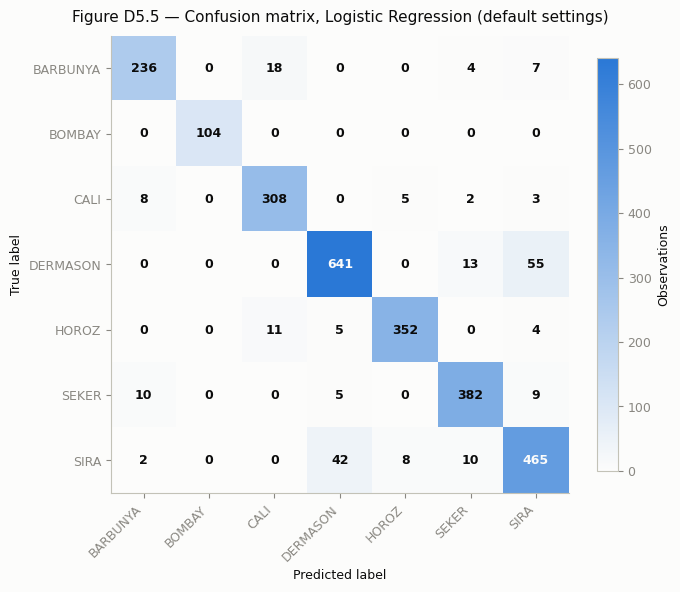

In [46]:
# 5.10 Confusion matrix, Logistic Regression
plot_confusion_matrix(
    logreg_results['confusion_matrix'],
    "Figure D5.5 — Confusion matrix, Logistic Regression (default settings)",
    "figD5_5_confusion_logreg.png",
)

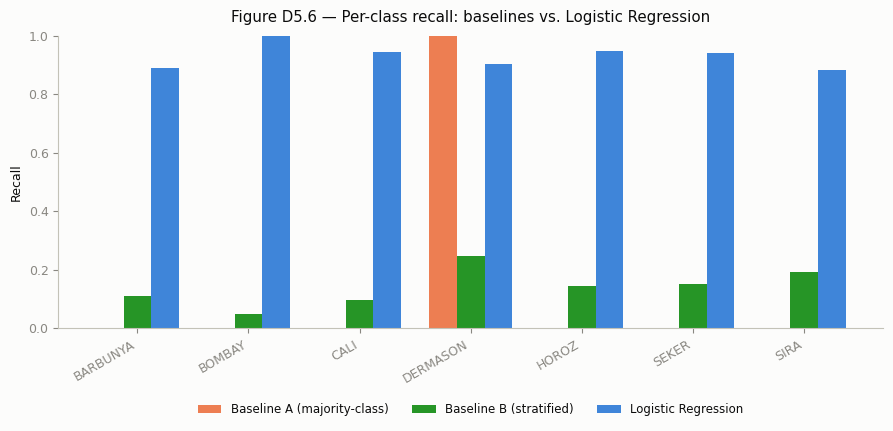

In [47]:
# 5.11 Per-class recall: both baselines + Logistic Regression

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(CLASS_ORDER))
width = 0.25
ax.bar(x - width, majority_results['per_class_recall'][CLASS_ORDER], width,
       label='Baseline A (majority-class)', color=CLASS_COLORS['BOMBAY'], alpha=0.85)
ax.bar(x, stratified_results['per_class_recall'][CLASS_ORDER], width,
       label='Baseline B (stratified)', color=CLASS_COLORS['SEKER'], alpha=0.85)
ax.bar(x + width, logreg_results['per_class_recall'][CLASS_ORDER], width,
       label='Logistic Regression', color=CLASS_COLORS['BARBUNYA'], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha='right')
ax.set_ylabel("Recall")
ax.set_ylim(0, 1)
ax.set_title("Figure D5.6 — Per-class recall: baselines vs. Logistic Regression")
# Legend moved below the plot (outside the axes) rather than inside, so it
# never overlaps a bar regardless of which classes are tall/short once this
# runs on the real data. `bbox_inches='tight'` in savefig() keeps the legend
# from being cropped out of the saved PNG.
ax.legend(frameon=False, fontsize=8.5, loc='upper center',
          bbox_to_anchor=(0.5, -0.22), ncol=3)
plt.tight_layout()
savefig("figD5_6_per_class_recall_with_logreg.png")
plt.show()

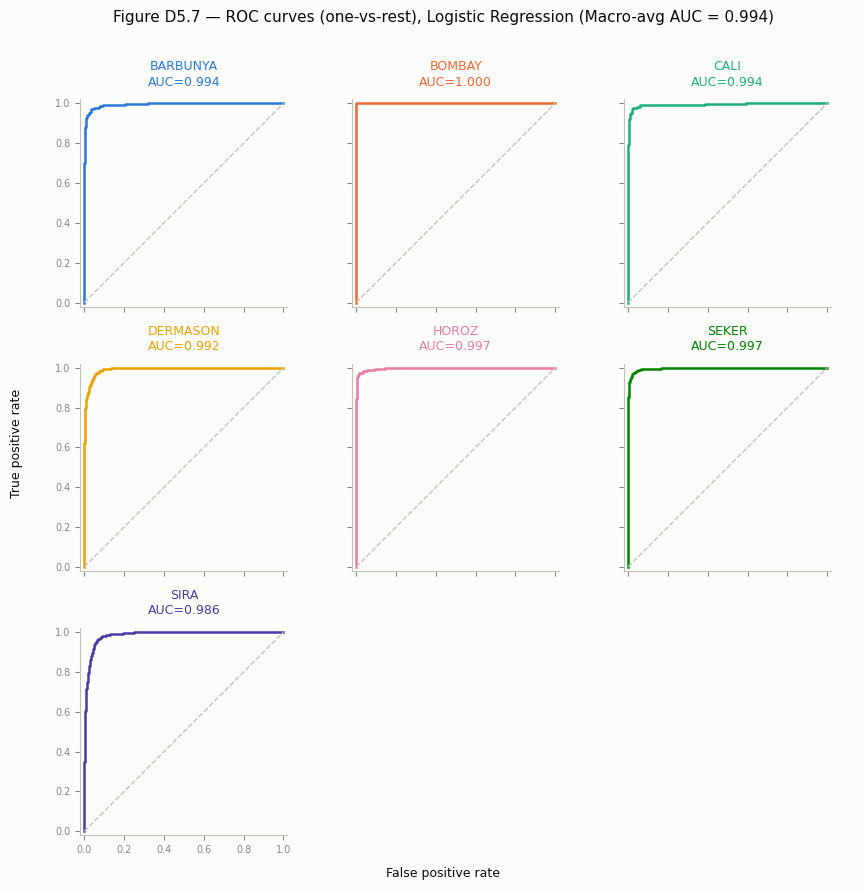

In [48]:
# 5.12 ROC curves (one-vs-rest), Logistic Regression

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

proba_df = pd.DataFrame(logreg_clf.predict_proba(X_test_scaled),
                         columns=logreg_clf.classes_)[CLASS_ORDER].values
y_test_bin = label_binarize(y_test, classes=CLASS_ORDER)

grid_cols = 3
grid_rows = int(np.ceil(len(CLASS_ORDER) / grid_cols))
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(8.5, 8.5), sharex=True, sharey=True)
axes = axes.flatten()

for i, c in enumerate(CLASS_ORDER):
    ax = axes[i]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_df[:, i])
    class_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=CLASS_COLORS[c], linewidth=1.8)
    ax.plot([0, 1], [0, 1], color=AXIS_COLOR, linestyle='--', linewidth=1.0)
    ax.set_title(f"{c}\nAUC={class_auc:.3f}", fontsize=9, color=CLASS_COLORS[c])
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
for j in range(len(CLASS_ORDER), len(axes)):
    axes[j].axis('off')

fig.suptitle(f"Figure D5.7 — ROC curves (one-vs-rest), Logistic Regression "
             f"(Macro-avg AUC = {logreg_results['roc_auc_macro_ovr']:.3f})", y=1.01, fontsize=11)
fig.text(0.5, -0.01, "False positive rate", ha='center', fontsize=9)
fig.text(-0.01, 0.5, "True positive rate", va='center', rotation='vertical', fontsize=9)
plt.tight_layout()
savefig("figD5_7_roc_curve_logreg.png")
plt.show()


In [49]:
# Logistic Regression (default settings) summary / working notes

print("=" * 70)
print("LOGISTIC REGRESSION (DEFAULT SETTINGS) SUMMARY")
print("=" * 70)
print(f"Accuracy: {logreg_results['accuracy']:.4f} | Macro F1: {logreg_results['f1_macro']:.4f} | "
      f"Macro recall: {logreg_results['recall_macro']:.4f} | Macro AUC: {logreg_results['roc_auc_macro_ovr']:.4f}")
print(f"\nClears the best baseline's macro F1 by "
      f"{improvement_over_best_baseline:.4f}" if improvement_over_best_baseline > 0 else
      "\nWARNING: does not yet clear the best baseline's macro F1 -- investigate before proceeding.")


LOGISTIC REGRESSION (DEFAULT SETTINGS) SUMMARY
Accuracy: 0.9184 | Macro F1: 0.9299 | Macro recall: 0.9298 | Macro AUC: 0.9944

Clears the best baseline's macro F1 by 0.7880


# Logistic Regression (Default Settings). Key Insights

**A 7-feature linear model jumps from a 0.14 macro-F1 floor to 0.93.** Baseline B (the honest floor) scored macro F1 = 0.1418; Logistic Regression reaches 0.9299, a +0.7880 gain. Accuracy (0.9184), macro F1 (0.9299), and macro recall (0.9298) all land within a point of each other, unlike the baselines' wildly diverging metrics, a first sign the model is genuinely learning class structure, not exploiting one dominant class.

**Precision, recall, and F1 are nearly identical (0.9301 / 0.9298 / 0.9299 macro).** No metric is quietly compensating for another, and macro approximates weighted throughout (0.9299 vs. 0.9185 F1), performance isn't concentrated in the large classes at smaller classes' expense, a real contrast with Baseline A's 6-of-7 blind spots.

**ROC-AUC (0.9944 macro OvR) confirms this isn't just favorable thresholding.** Near-perfect ranking ability across all 7 one-vs-rest problems, up from  approximatelly 0.50 (chance) for both baselines, the model separates classes on probability, not just on the default 0.5 cutoff.

**BOMBAY hits perfect recall (1.0000), exactly as EDA predicted.** BOMBAY's near-total isolation on Area alone (Figure D2.3a) was flagged as "needs no clever feature engineering to detect", confirmed here with zero errors, even after Area's collinear siblings were VIF-pruned down to 7 features total.

**SIRA (0.8824) and BARBUNYA (0.8906) are the weakest classes, also exactly as EDA predicted.** The EDA insights called SIRA "the hardest single class to isolate with any one or two variables," sitting mid-distribution on nearly every feature; BARBUNYA was flagged alongside CALI as still overlapping in the 2D Area × ShapeFactor2 view. Both now show up as the two lowest-recall classes,  approximatelly 6-11 points behind the rest, the model resolves most of that 2D ambiguity but not all of it.

**HOROZ and SEKER, the shape extremes, both do well (0.9462, 0.9409).** Consistent with them sitting at opposite ends of Eccentricity/AspectRation/Compactness in the EDA: distinct shape signatures are as learnable as BOMBAY's size signature, just not perfectly so.

**Convergence and fit diagnostics are clean.** 58 of 1000 allowed iterations , well short of the cap, no convergence warning risk. Coefficient matrix is (7 classes × 7 features), confirming a true multinomial softmax fit (one row per class) on the VIF-selected feature set, not a one-vs-rest fallback.



In [50]:
# FINAL PROJECT DAY 7 (LOGISTIC REGRESSION TUNING, RUN AHEAD OF SCHEDULE)

import warnings
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("Tuning Logistic Regression on X_train_scaled:", X_train_scaled.shape)

Tuning Logistic Regression on X_train_scaled: (10834, 7)


In [51]:
# 7.1 Hand-picked exploration (before the systematic search)

cv_probe = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

hand_picked_configs = [
    ("Default (C=1.0, l2, no class_weight)",
     LogisticRegression(solver='saga', max_iter=5000, random_state=RANDOM_SEED)),
    ("Strong regularization (C=0.01, l2)",
     LogisticRegression(C=0.01, solver='saga', max_iter=5000, random_state=RANDOM_SEED)),
    ("Weak regularization (C=10, l2)",
     LogisticRegression(C=10, solver='saga', max_iter=5000, random_state=RANDOM_SEED)),
    ("L1 penalty (C=1.0, saga)",
     LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=RANDOM_SEED)),
    ("class_weight='balanced' (C=1.0, l2)",
     LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=RANDOM_SEED)),
]

print("\n7.1 Hand-picked configurations -- mean CV macro F1 (5-fold stratified):")
from sklearn.metrics import f1_score

probe_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    warnings.simplefilter("ignore", UserWarning)
    for label, est in hand_picked_configs:
        scores = []
        for train_idx, val_idx in cv_probe.split(X_train_scaled, y_train):
            est.fit(X_train_scaled.iloc[train_idx], y_train.iloc[train_idx])
            preds = est.predict(X_train_scaled.iloc[val_idx])
            scores.append(f1_score(y_train.iloc[val_idx], preds, average='macro'))
        scores = np.array(scores)
        probe_rows.append({'Configuration': label, 'Mean CV macro F1': scores.mean(), 'Std': scores.std()})
        print(f"  {label:42s} mean CV macro F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")
probe_df = pd.DataFrame(probe_rows)



7.1 Hand-picked configurations -- mean CV macro F1 (5-fold stratified):
  Default (C=1.0, l2, no class_weight)       mean CV macro F1 = 0.9367 (+/- 0.0045)
  Strong regularization (C=0.01, l2)         mean CV macro F1 = 0.9236 (+/- 0.0082)
  Weak regularization (C=10, l2)             mean CV macro F1 = 0.9385 (+/- 0.0034)
  L1 penalty (C=1.0, saga)                   mean CV macro F1 = 0.9372 (+/- 0.0042)
  class_weight='balanced' (C=1.0, l2)        mean CV macro F1 = 0.9335 (+/- 0.0050)


In [52]:
# 7.2 Systematic search: GridSearchCV over C, penalty, class_weight

LOGREG_PARAM_GRID = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced'],
}
cv_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

logreg_search = GridSearchCV(
    LogisticRegression(solver='saga', max_iter=5000, random_state=RANDOM_SEED),
    param_grid=LOGREG_PARAM_GRID,
    scoring='f1_macro',
    cv=cv_search,
    n_jobs=-1,
    refit=True,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    warnings.simplefilter("ignore", UserWarning)
    logreg_search.fit(X_train_scaled, y_train)

n_candidates = len(logreg_search.cv_results_['params'])
print(f"\n7.2 Grid search: {n_candidates} candidate configurations x "
      f"{cv_search.get_n_splits()} folds = {n_candidates * cv_search.get_n_splits()} fits")
print("Best CV macro F1:", round(logreg_search.best_score_, 4))
print("Best params:", logreg_search.best_params_)

print("\nTop 10 candidates by mean CV macro F1 (tuning evidence for the report):")
cv_results_df = pd.DataFrame(logreg_search.cv_results_)
top10 = cv_results_df.sort_values('mean_test_score', ascending=False).head(10)[
    ['param_C', 'param_penalty', 'param_class_weight', 'mean_test_score', 'std_test_score']
]
print(top10.round(4).to_string(index=False))



7.2 Grid search: 24 candidate configurations x 5 folds = 120 fits
Best CV macro F1: 0.9385
Best params: {'C': 10, 'class_weight': None, 'penalty': 'l2'}

Top 10 candidates by mean CV macro F1 (tuning evidence for the report):
 param_C param_penalty param_class_weight  mean_test_score  std_test_score
    10.0            l2               None           0.9385          0.0034
    10.0            l1               None           0.9377          0.0039
   100.0            l1               None           0.9377          0.0039
   100.0            l2               None           0.9376          0.0040
     1.0            l1               None           0.9372          0.0042
     1.0            l2               None           0.9367          0.0045
     0.1            l2               None           0.9356          0.0041
     0.1            l1               None           0.9341          0.0048
     1.0            l2           balanced           0.9335          0.0050
    10.0            l2 

In [53]:

# 7.3 Final tuned model: evaluate on the held-out test set

logreg_tuned = logreg_search.best_estimator_
logreg_tuned_results = evaluate_baseline(
    logreg_tuned, X_train_scaled, X_test_scaled, y_train, y_test,
    "Logistic Regression (tuned)"
)

print(f"\nTuned solver: {logreg_tuned.solver} | C={logreg_tuned.C} | "
      f"class_weight={logreg_tuned.class_weight} "
      f"(penalty selected by the search: {logreg_search.best_params_['penalty']})")
print(f"Coefficient matrix shape: {logreg_tuned.coef_.shape} "
      f"({len(CLASS_ORDER)} classes x {logreg_tuned.coef_.shape[1]} features -- "
      f"still a genuine multinomial fit after tuning, not OvR)")



Logistic Regression (tuned)
Accuracy:            0.9188
Precision (macro):   0.9306   | (weighted): 0.9194
Recall (macro):      0.9302   | (weighted): 0.9188
F1-score (macro):    0.9302   | (weighted): 0.9189
ROC-AUC (macro OvR): 0.9946

Per-class recall:
BARBUNYA    0.8906
BOMBAY      1.0000
CALI        0.9479
DERMASON    0.9041
HOROZ       0.9435
SEKER       0.9409
SIRA        0.8843
dtype: float64

Tuned solver: saga | C=10 | class_weight=None (penalty selected by the search: l2)
Coefficient matrix shape: (7, 7) (7 classes x 7 features -- still a genuine multinomial fit after tuning, not OvR)


In [54]:
# 7.4 Default-settings vs. tuned Logistic Regression
summary_cols = ['name', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
                 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc_macro_ovr']
tuning_comparison = pd.DataFrame([logreg_results, logreg_tuned_results])[summary_cols]
print("\n" + "=" * 70)
print("Logistic Regression: default settings vs. tuned")
print("=" * 70)
print(tuning_comparison.round(4).to_string(index=False))

tuning_gain = logreg_tuned_results['f1_macro'] - logreg_results['f1_macro']
print(f"\nMacro F1 change from tuning: {'+' if tuning_gain >= 0 else ''}{tuning_gain:.4f} "
      f"({logreg_results['f1_macro']:.4f} -> {logreg_tuned_results['f1_macro']:.4f})")
if tuning_gain < 0:
    print("NOTE: tuning did not improve macro F1 on the test set -- this is a valid, "
          "reportable outcome (it means the Day 5 defaults were already close to optimal "
          "for this feature set), not a bug to chase.")

print("\nPer-class recall, default vs. tuned:")
recall_compare = pd.DataFrame({
    'default': logreg_results['per_class_recall'],
    'tuned': logreg_tuned_results['per_class_recall'],
})
recall_compare['change'] = recall_compare['tuned'] - recall_compare['default']
print(recall_compare.round(4))


Logistic Regression: default settings vs. tuned
                                               name  accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  recall_weighted  f1_weighted  roc_auc_macro_ovr
Logistic Regression (multinomial, default settings)    0.9184           0.9301        0.9298    0.9299              0.9190           0.9184       0.9185             0.9944
                        Logistic Regression (tuned)    0.9188           0.9306        0.9302    0.9302              0.9194           0.9188       0.9189             0.9946

Macro F1 change from tuning: +0.0004 (0.9299 -> 0.9302)

Per-class recall, default vs. tuned:
          default   tuned  change
BARBUNYA   0.8906  0.8906  0.0000
BOMBAY     1.0000  1.0000  0.0000
CALI       0.9448  0.9479  0.0031
DERMASON   0.9041  0.9041  0.0000
HOROZ      0.9462  0.9435 -0.0027
SEKER      0.9409  0.9409  0.0000
SIRA       0.8824  0.8843  0.0019


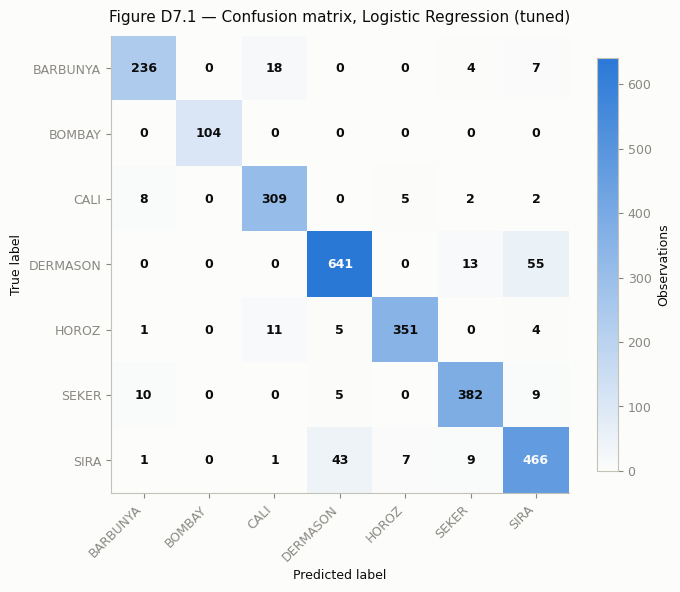

In [55]:
# 7.5 Confusion matrix, tuned Logistic Regression
plot_confusion_matrix(
    logreg_tuned_results['confusion_matrix'],
    "Figure D7.1 — Confusion matrix, Logistic Regression (tuned)",
    "figD7_1_confusion_logreg_tuned.png",
)

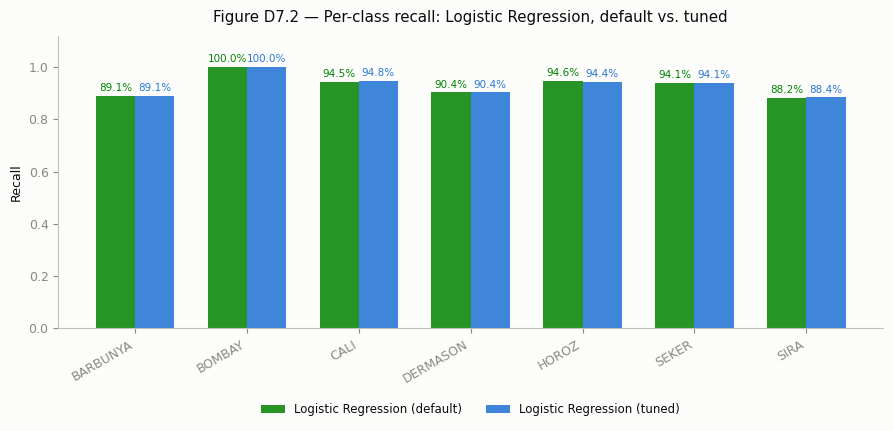

In [56]:
# 7.6 Per-class recall: default vs. tuned Logistic Regression

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(CLASS_ORDER))
width = 0.35
bars_default = ax.bar(x - width / 2, logreg_results['per_class_recall'][CLASS_ORDER], width,
                       label='Logistic Regression (default)', color=CLASS_COLORS['SEKER'], alpha=0.85)
bars_tuned = ax.bar(x + width / 2, logreg_tuned_results['per_class_recall'][CLASS_ORDER], width,
                     label='Logistic Regression (tuned)', color=CLASS_COLORS['BARBUNYA'], alpha=0.9)
ax.bar_label(bars_default,
             labels=[f"{v * 100:.1f}%" for v in logreg_results['per_class_recall'][CLASS_ORDER]],
             padding=2, fontsize=7.5, color=CLASS_COLORS['SEKER'])
ax.bar_label(bars_tuned,
             labels=[f"{v * 100:.1f}%" for v in logreg_tuned_results['per_class_recall'][CLASS_ORDER]],
             padding=2, fontsize=7.5, color=CLASS_COLORS['BARBUNYA'])
ax.set_xticks(x)
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha='right')
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.12)  # headroom above the 100% bars so the labels never clip
ax.set_title("Figure D7.2 — Per-class recall: Logistic Regression, default vs. tuned")
ax.legend(frameon=False, fontsize=8.5, loc='upper center',
          bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
savefig("figD7_2_per_class_recall_logreg_tuned.png")
plt.show()


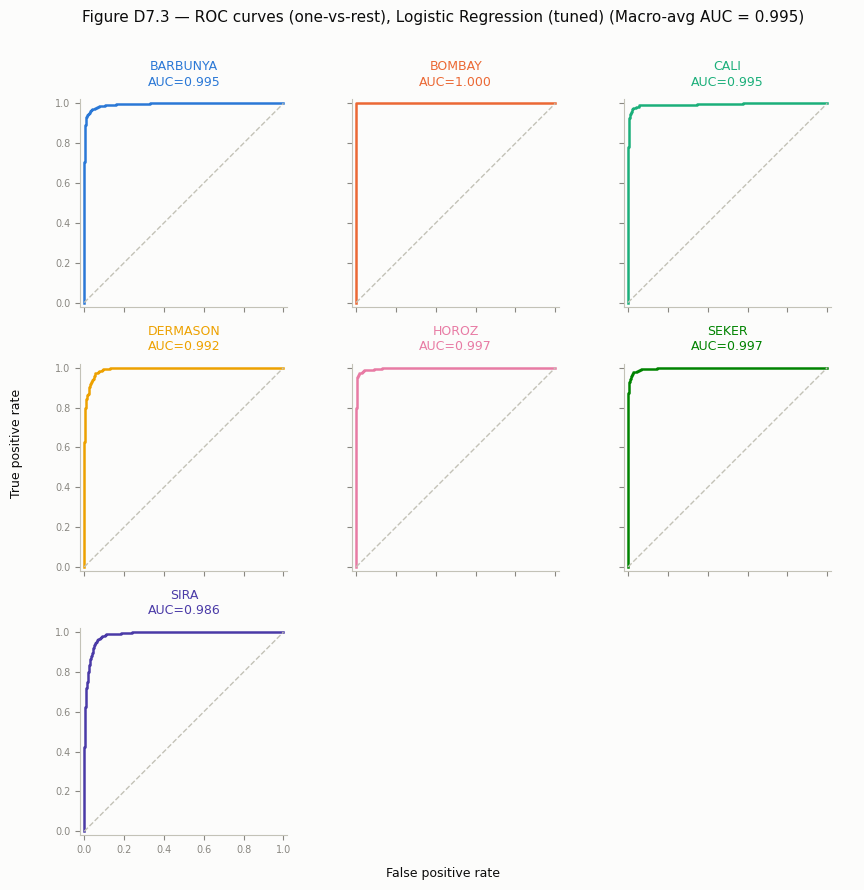

In [57]:
# 7.7 ROC curves (one-vs-rest), tuned Logistic Regression, small multiples
# Same 3x3 small-multiples layout as Figure D5.7, applied to the tuned model.

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

proba_tuned = pd.DataFrame(logreg_tuned.predict_proba(X_test_scaled),
                            columns=logreg_tuned.classes_)[CLASS_ORDER].values
y_test_bin = label_binarize(y_test, classes=CLASS_ORDER)

grid_cols = 3
grid_rows = int(np.ceil(len(CLASS_ORDER) / grid_cols))
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(8.5, 8.5), sharex=True, sharey=True)
axes = axes.flatten()

for i, c in enumerate(CLASS_ORDER):
    ax = axes[i]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_tuned[:, i])
    class_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=CLASS_COLORS[c], linewidth=1.8)
    ax.plot([0, 1], [0, 1], color=AXIS_COLOR, linestyle='--', linewidth=1.0)
    ax.set_title(f"{c}\nAUC={class_auc:.3f}", fontsize=9, color=CLASS_COLORS[c])
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
for j in range(len(CLASS_ORDER), len(axes)):
    axes[j].axis('off')

fig.suptitle(f"Figure D7.3 — ROC curves (one-vs-rest), Logistic Regression (tuned) "
             f"(Macro-avg AUC = {logreg_tuned_results['roc_auc_macro_ovr']:.3f})", y=1.01, fontsize=11)
fig.text(0.5, -0.01, "False positive rate", ha='center', fontsize=9)
fig.text(-0.01, 0.5, "True positive rate", va='center', rotation='vertical', fontsize=9)
plt.tight_layout()
savefig("figD7_3_roc_curve_logreg_tuned.png")
plt.show()

In [58]:
# =========================================================
# Logistic Regression tuning summary / working notes
# =========================================================
print("=" * 70)
print("LOGISTIC REGRESSION TUNING SUMMARY")
print("=" * 70)
print(f"Best CV macro F1: {logreg_search.best_score_:.4f} | Best params: {logreg_search.best_params_}")
print(f"Test-set macro F1: default={logreg_results['f1_macro']:.4f} -> "
      f"tuned={logreg_tuned_results['f1_macro']:.4f} ({tuning_gain:+.4f})")
print(f"Test-set macro AUC: default={logreg_results['roc_auc_macro_ovr']:.4f} -> "
      f"tuned={logreg_tuned_results['roc_auc_macro_ovr']:.4f}")
print(f"\nWeakest class (tuned): {logreg_tuned_results['per_class_recall'].idxmin()} "
      f"(recall={logreg_tuned_results['per_class_recall'].min():.4f})")
print("\nSave for the report's Modeling section: the full cv_results_ table (tuning evidence, "
      "not just the final numbers) and the best_params_ dict, plus a stated justification of "
      "whichever of C / penalty / class_weight the search selected -- tying class_weight's "
      "effect (if selected) back to the Day 4 audit's 6.79x DERMASON:BOMBAY imbalance ratio.")
print("\nCoefficient interpretation remains deferred to the dedicated Interpretation step "
      "(Day 10), now against this tuned model rather than the Day 5 default-settings one.")
print("\nNext: Random Forest and XGBoost initial fits, then their own tuning, per the team plan.")

LOGISTIC REGRESSION TUNING SUMMARY
Best CV macro F1: 0.9385 | Best params: {'C': 10, 'class_weight': None, 'penalty': 'l2'}
Test-set macro F1: default=0.9299 -> tuned=0.9302 (+0.0004)
Test-set macro AUC: default=0.9944 -> tuned=0.9946

Weakest class (tuned): SIRA (recall=0.8843)

Save for the report's Modeling section: the full cv_results_ table (tuning evidence, not just the final numbers) and the best_params_ dict, plus a stated justification of whichever of C / penalty / class_weight the search selected -- tying class_weight's effect (if selected) back to the Day 4 audit's 6.79x DERMASON:BOMBAY imbalance ratio.

Coefficient interpretation remains deferred to the dedicated Interpretation step (Day 10), now against this tuned model rather than the Day 5 default-settings one.

Next: Random Forest and XGBoost initial fits, then their own tuning, per the team plan.


# Logistic Regression Tuning. Key Insights

**Tuning barely moved the needle: +0.0004 macro F1, +0.0002 macro AUC.** The 24-config grid search (C × penalty × class_weight, 5-fold stratified CV) landed on C=10, l2, no class_weight, test-set macro F1 goes from 0.9299 (default) to 0.9302, accuracy 0.9184 to 0.9188, macro AUC 0.9944 to 0.9946. This is a genuine, reportable result, not a failed search: it means the Day 5 defaults were already close to optimal for this 7-feature set, so there was little headroom left for a linear model to gain from hyperparameters alone.

**The winning config is nearly identical to the default, which explains why nothing moved.** Best CV macro F1 (0.9385) came from C=10 (weaker regularization than the default C=1), the same l2 penalty, and no class weighting. The hand-picked probes bracket this cleanly: strong regularization (C=0.01) clearly hurt (0.9236), while weak regularization (C=10) and the default (C=1) both landed within half a point of each other (0.9385 vs. 0.9367), the model was never meaningfully over- or under-regularized to begin with.

**class_weight='balanced' made things worse, not better (0.9335 CV macro F1 vs. 0.9367–0.9385 unweighted).** In the top-10 grid results, every configuration with class_weight=None outranks every 'balanced' one. This directly tests Day 4's deferred imbalance decision: the 6.79x DERMASON:BOMBAY ratio was judged "moderate, not extreme," with the actual call left for later evidence, this is that evidence, and it says don't intervene. The softmax fit already handles this imbalance without help; forcibly reweighting classes trades away accuracy on the well-separated classes (BOMBAY, DERMASON) without a compensating gain elsewhere.

**Per-class recall changes are within noise for every class.** CALI +0.31pp, SIRA +0.19pp, HOROZ -0.27pp, and BARBUNYA/BOMBAY/DERMASON/SEKER unchanged entirely. No class was meaningfully helped or hurt by tuning, consistent with the CV evidence that the search only found a marginally different point in a fairly flat region of the C/penalty/class_weight space.

**SIRA is still the weakest class (88.43% recall), essentially untouched by tuning.** This matches the EDA's original flag that SIRA sits mid-distribution on nearly every feature and is "the hardest single class to isolate", a regularization or class-weighting knob can't resolve genuine feature-level overlap between classes; only a model with more capacity to draw a non-linear boundary (or better features) could plausibly help here.

**What this sets up for Random Forest and XGBoost:**
- The bar to beat is now a *tuned* linear model at 0.9302 macro F1 / 0.9946 macro AUC, tree-based models need to show real gains from nonlinearity, not just from having more knobs to turn.
- SIRA (and secondarily BARBUNYA, 89.06% recall, unchanged by tuning) are the two classes to watch, if Random Forest/XGBoost also plateau there, it's stronger evidence the overlap is in the feature space itself, not a modeling-technique limitation.
- The class-weighting question is worth re-testing per model rather than assumed settled: tree-based models handle imbalance differently (via split criteria, not a loss reweighting), so 'balanced' hurting Logistic Regression doesn't predict what it will do for Random Forest.


In [59]:
# FINAL PROJECT: RANDOM FOREST, INITIAL FIT (DEFAULT SETTINGS)

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

print("Fitting Random Forest on X_train (raw, unscaled, VIF-selected features):", X_train.shape)

Fitting Random Forest on X_train (raw, unscaled, VIF-selected features): (10834, 7)


In [60]:
# 7.8 Fit and evaluate Random Forest (default settings)

rf_clf = RandomForestClassifier(random_state=RANDOM_SEED)
rf_results = evaluate_baseline(
    rf_clf, X_train, X_test, y_train, y_test,
    "Random Forest (default settings)"
)

tree_depths = [est.get_depth() for est in rf_clf.estimators_]
tree_leaves = [est.get_n_leaves() for est in rf_clf.estimators_]
print(f"\n{rf_clf.n_estimators} trees | avg depth = {np.mean(tree_depths):.1f} "
      f"(min {min(tree_depths)}, max {max(tree_depths)}) | "
      f"avg leaves = {np.mean(tree_leaves):.1f}")
print("No max_depth constraint applied yet -- fully grown, unconstrained trees "
      "are a real overfitting risk to watch for once train-vs-test performance "
      "is compared, and a natural first thing to probe in tuning.")
print(f"\nTrain accuracy: {rf_clf.score(X_train, y_train):.4f} | "
      f"Test accuracy: {rf_results['accuracy']:.4f} "
      f"(a large gap here would be the overfitting signal to watch for)")


Random Forest (default settings)
Accuracy:            0.9169
Precision (macro):   0.9302   | (weighted): 0.9172
Recall (macro):      0.9277   | (weighted): 0.9169
F1-score (macro):    0.9288   | (weighted): 0.9170
ROC-AUC (macro OvR): 0.9933

Per-class recall:
BARBUNYA    0.8981
BOMBAY      1.0000
CALI        0.9356
DERMASON    0.9196
HOROZ       0.9274
SEKER       0.9557
SIRA        0.8577
dtype: float64

100 trees | avg depth = 22.8 (min 19, max 34) | avg leaves = 665.8
No max_depth constraint applied yet -- fully grown, unconstrained trees are a real overfitting risk to watch for once train-vs-test performance is compared, and a natural first thing to probe in tuning.

Train accuracy: 1.0000 | Test accuracy: 0.9169 (a large gap here would be the overfitting signal to watch for)


In [61]:
# 7.9 Model comparison so far: baselines, Logistic Regression, Random Forest

summary_cols = ['name', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
                 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc_macro_ovr']
model_comparison = pd.DataFrame([
    majority_results, stratified_results, logreg_results, logreg_tuned_results, rf_results
])[summary_cols]
print("\n" + "=" * 70)
print("Model comparison: baselines, Logistic Regression (default/tuned), Random Forest")
print("=" * 70)
print(model_comparison.round(4).to_string(index=False))

rf_vs_logreg = rf_results['f1_macro'] - logreg_tuned_results['f1_macro']
print(f"\nRandom Forest vs. tuned Logistic Regression, macro F1: "
      f"{'+' if rf_vs_logreg >= 0 else ''}{rf_vs_logreg:.4f} "
      f"({logreg_tuned_results['f1_macro']:.4f} -> {rf_results['f1_macro']:.4f})")
print("\nPer-class recall (Random Forest):")
print(rf_results['per_class_recall'].round(4))
print("\nWeakest class by recall:", rf_results['per_class_recall'].idxmin(),
      f"({rf_results['per_class_recall'].min():.4f})")
print("Strongest class by recall:", rf_results['per_class_recall'].idxmax(),
      f"({rf_results['per_class_recall'].max():.4f})")


Model comparison: baselines, Logistic Regression (default/tuned), Random Forest
                                                       name  accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  recall_weighted  f1_weighted  roc_auc_macro_ovr
    Baseline A: Majority-class (always predicts 'DERMASON')    0.2617           0.0374        0.1429    0.0593              0.0685           0.2617       0.1086             0.5000
Baseline B: Stratified random (base-rate-weighted guessing)    0.1694           0.1420        0.1418    0.1418              0.1687           0.1694       0.1690             0.4991
        Logistic Regression (multinomial, default settings)    0.9184           0.9301        0.9298    0.9299              0.9190           0.9184       0.9185             0.9944
                                Logistic Regression (tuned)    0.9188           0.9306        0.9302    0.9302              0.9194           0.9188       0.9189             0.9946
                   

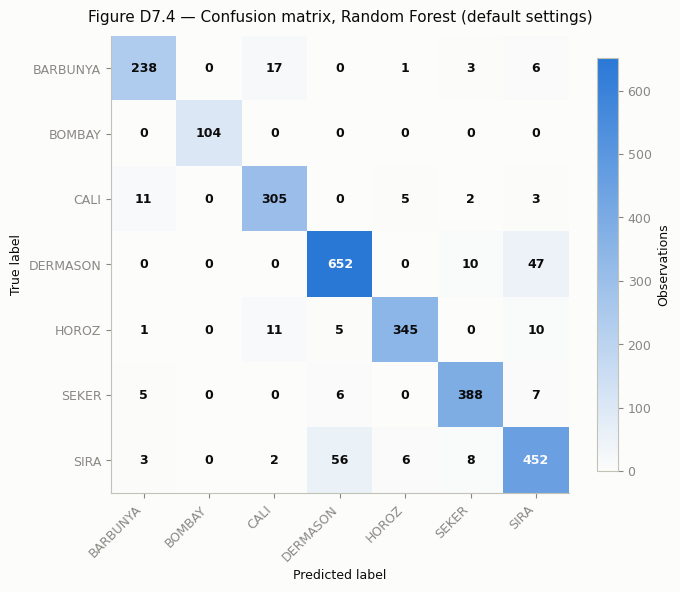

In [62]:
# 7.10 Confusion matrix, Random Forest
plot_confusion_matrix(
    rf_results['confusion_matrix'],
    "Figure D7.4 — Confusion matrix, Random Forest (default settings)",
    "figD7_4_confusion_random_forest.png",
)

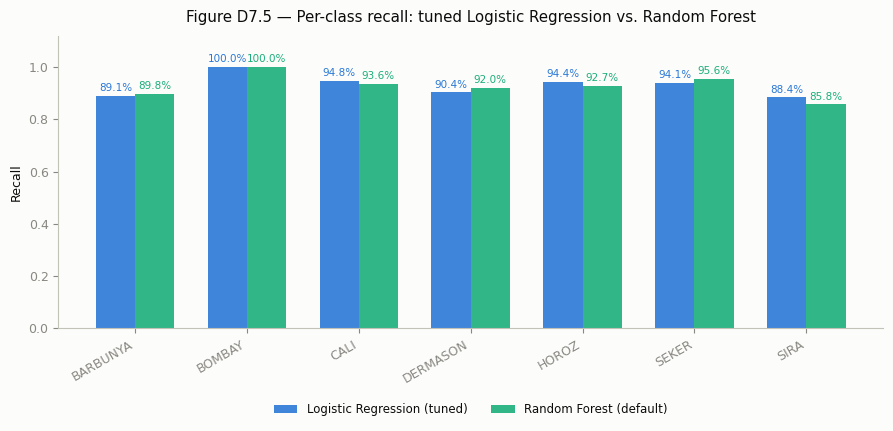

In [63]:
# 7.11 Per-class recall: tuned Logistic Regression vs. Random Forest

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(CLASS_ORDER))
width = 0.35
bars_lr = ax.bar(x - width / 2, logreg_tuned_results['per_class_recall'][CLASS_ORDER], width,
                  label='Logistic Regression (tuned)', color=CLASS_COLORS['BARBUNYA'], alpha=0.9)
bars_rf = ax.bar(x + width / 2, rf_results['per_class_recall'][CLASS_ORDER], width,
                  label='Random Forest (default)', color=CLASS_COLORS['CALI'], alpha=0.9)
ax.bar_label(bars_lr,
             labels=[f"{v * 100:.1f}%" for v in logreg_tuned_results['per_class_recall'][CLASS_ORDER]],
             padding=2, fontsize=7.5, color=CLASS_COLORS['BARBUNYA'])
ax.bar_label(bars_rf,
             labels=[f"{v * 100:.1f}%" for v in rf_results['per_class_recall'][CLASS_ORDER]],
             padding=2, fontsize=7.5, color=CLASS_COLORS['CALI'])
ax.set_xticks(x)
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha='right')
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.12)
ax.set_title("Figure D7.5 — Per-class recall: tuned Logistic Regression vs. Random Forest")
ax.legend(frameon=False, fontsize=8.5, loc='upper center',
          bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
savefig("figD7_5_per_class_recall_rf_vs_logreg.png")
plt.show()

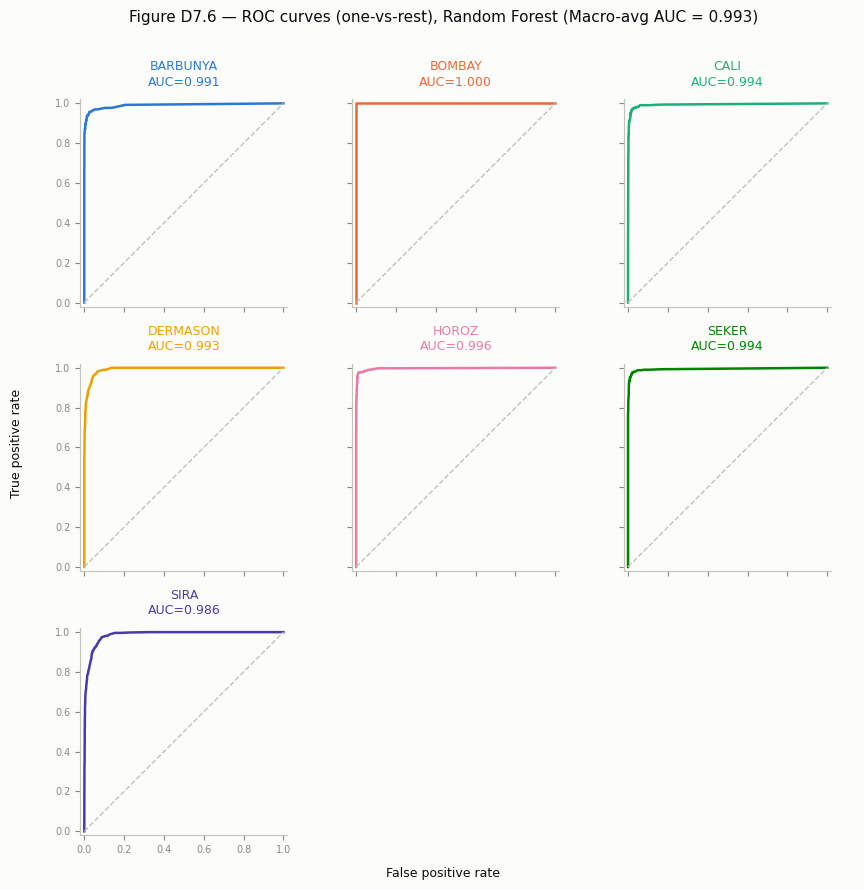

In [64]:
# 7.12 ROC curves (one-vs-rest), Random Forest -- small multiples

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

proba_rf = pd.DataFrame(rf_clf.predict_proba(X_test),
                         columns=rf_clf.classes_)[CLASS_ORDER].values
y_test_bin = label_binarize(y_test, classes=CLASS_ORDER)

grid_cols = 3
grid_rows = int(np.ceil(len(CLASS_ORDER) / grid_cols))
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(8.5, 8.5), sharex=True, sharey=True)
axes = axes.flatten()

for i, c in enumerate(CLASS_ORDER):
    ax = axes[i]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_rf[:, i])
    class_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=CLASS_COLORS[c], linewidth=1.8)
    ax.plot([0, 1], [0, 1], color=AXIS_COLOR, linestyle='--', linewidth=1.0)
    ax.set_title(f"{c}\nAUC={class_auc:.3f}", fontsize=9, color=CLASS_COLORS[c])
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
for j in range(len(CLASS_ORDER), len(axes)):
    axes[j].axis('off')

fig.suptitle(f"Figure D7.6 — ROC curves (one-vs-rest), Random Forest "
             f"(Macro-avg AUC = {rf_results['roc_auc_macro_ovr']:.3f})", y=1.01, fontsize=11)
fig.text(0.5, -0.01, "False positive rate", ha='center', fontsize=9)
fig.text(-0.01, 0.5, "True positive rate", va='center', rotation='vertical', fontsize=9)
plt.tight_layout()
savefig("figD7_6_roc_curve_random_forest.png")
plt.show()

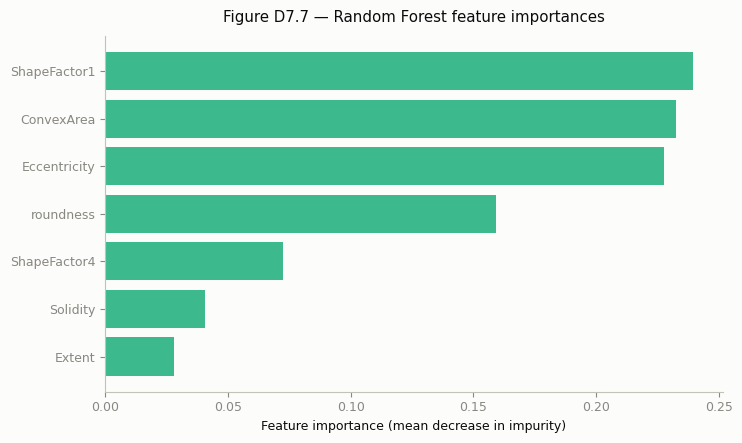


Feature importance ranking:
ShapeFactor1    0.2397
ConvexArea      0.2325
Eccentricity    0.2278
roundness       0.1591
ShapeFactor4    0.0725
Solidity        0.0405
Extent          0.0279
dtype: float64


In [65]:
# 7.13 Feature importances, Random Forest

importances = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.barh(importances.index, importances.values, color=CLASS_COLORS['CALI'], alpha=0.85)
ax.set_xlabel("Feature importance (mean decrease in impurity)")
ax.set_title("Figure D7.7 — Random Forest feature importances")
plt.tight_layout()
savefig("figD7_7_feature_importance_random_forest.png")
plt.show()

print("\nFeature importance ranking:")
print(importances.sort_values(ascending=False).round(4))

In [66]:
# Random Forest (default settings) summary / working notes

print("=" * 70)
print("RANDOM FOREST (DEFAULT SETTINGS) SUMMARY")
print("=" * 70)
print(f"Accuracy: {rf_results['accuracy']:.4f} | Macro F1: {rf_results['f1_macro']:.4f} | "
      f"Macro recall: {rf_results['recall_macro']:.4f} | Macro AUC: {rf_results['roc_auc_macro_ovr']:.4f}")
print(f"\nvs. tuned Logistic Regression macro F1 ({logreg_tuned_results['f1_macro']:.4f}): "
      f"{'+' if rf_vs_logreg >= 0 else ''}{rf_vs_logreg:.4f}" if rf_vs_logreg != 0 else
      "\nEssentially tied with tuned Logistic Regression on macro F1.")
print(f"Weakest class: {rf_results['per_class_recall'].idxmin()} "
      f"(recall={rf_results['per_class_recall'].min():.4f}) -- compare against "
      f"Logistic Regression's weakest class (SIRA) to see whether the same class "
      f"is hard for every model (feature-overlap signal) or model-specific.")
print(f"\nTop feature by importance: {importances.idxmax()} ({importances.max():.4f}) -- "
      f"worth comparing against Logistic Regression's coefficients once both are "
      f"interpreted together in Day 10.")
print("\nNote: this is the INITIAL fit at default settings -- unconstrained tree depth "
      "is a real overfitting risk (see the train-vs-test accuracy gap printed in 7.8) "
      "and is exactly what systematic tuning (max_depth, min_samples_leaf, "
      "n_estimators, class_weight) should address next.")
print("\nNext: XGBoost initial fit, then systematic tuning for both Random Forest and XGBoost.")

RANDOM FOREST (DEFAULT SETTINGS) SUMMARY
Accuracy: 0.9169 | Macro F1: 0.9288 | Macro recall: 0.9277 | Macro AUC: 0.9933

vs. tuned Logistic Regression macro F1 (0.9302): -0.0014
Weakest class: SIRA (recall=0.8577) -- compare against Logistic Regression's weakest class (SIRA) to see whether the same class is hard for every model (feature-overlap signal) or model-specific.

Top feature by importance: ShapeFactor1 (0.2397) -- worth comparing against Logistic Regression's coefficients once both are interpreted together in Day 10.

Note: this is the INITIAL fit at default settings -- unconstrained tree depth is a real overfitting risk (see the train-vs-test accuracy gap printed in 7.8) and is exactly what systematic tuning (max_depth, min_samples_leaf, n_estimators, class_weight) should address next.

Next: XGBoost initial fit, then systematic tuning for both Random Forest and XGBoost.


# Random Forest (Default Settings). Key Insights

**A tree ensemble and a tuned linear model land in almost the same place: macro F1 0.9288 vs. 0.9302 (-0.0014).** Random Forest's default fit essentially ties tuned Logistic Regression: accuracy 0.9169 vs. 0.9188, macro AUC 0.9933 vs. 0.9946. Two very different model families converging on nearly the same ceiling is itself informative: it suggests the 7-feature VIF-selected set is close to linearly separable, so a tree's extra capacity for nonlinear splits isn't buying much here yet.

**The overfitting signature is textbook, but the ensemble is compensating for it.** Train accuracy is a perfect 1.0000 against 0.9169 on test, unconstrained trees (avg depth 22.8, ~666 leaves each) memorize the training set, exactly as flagged going in. Yet averaging 100 such trees still lands within half a point of the tuned linear model on the held-out set. This is the clearest argument for tuning `max_depth`/`min_samples_leaf` next: not because test performance looks bad, but because trusting feature importances or pushing accuracy further on an unconstrained forest is standing on a shakier foundation than the test numbers alone suggest.

**SIRA is the weakest class for both models now (RF 0.8577 vs. LR-tuned 0.8843).** This is the first real cross-model confirmation of the EDA's original read: SIRA sits mid-distribution on nearly every feature, and now two structurally different classifiers — one linear, one an ensemble of trees, both struggle with it most. That shifts the likely explanation from "linear model can't draw the right boundary" to "the classes genuinely overlap in this feature space," which no amount of tuning either model is likely to fully resolve.

**BARBUNYA is the one class Random Forest reads better than Logistic Regression (0.8981 vs. 0.8906).** A small gap, but in the opposite direction from SIRA, a hint that BARBUNYA's confusion involves at least some nonlinear structure a tree can exploit that a linear boundary can't, worth revisiting once both models are tuned.

**BOMBAY hits perfect recall again (1.0000), the fourth model family in a row to nail it.** Confirms once more that BOMBAY's separation is essentially a solved problem from size alone; it's not a benchmark either remaining model (XGBoost, or tuned versions) needs to be judged on.

**Feature importances put ~70% of the ensemble's weight on just three features: ShapeFactor1 (0.240), ConvexArea (0.233), and Eccentricity (0.228).** ConvexArea is notable, a size-derived feature that survived VIF elimination (unlike Area, which the audit flagged as its near-perfect collinear twin) and still carries real weight in the ensemble. This lines up with BOMBAY's perfect recall via size, while ShapeFactor1/Eccentricity carry the shape-based signal that separates the harder middle classes, good material to set against Logistic Regression's coefficients in the Day 10 interpretation step.

**What this sets up next:**
- Since default Random Forest already matches tuned Logistic Regression, tuning's job here is controlling overfitting and squeezing a modest gain, not closing a large gap.
- SIRA is now a two-model problem, not a one-model quirk, worth naming explicitly in the report as a likely feature-space limitation rather than a fixable modeling choice.
- XGBoost is the real remaining test of whether a stronger model can push past this ~0.93 macro F1 ceiling, or whether all three families converge here.


In [67]:
# FINAL PROJECT -- DAY 7/8: RANDOM FOREST TUNING


import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

print("Tuning Random Forest on X_train (raw, unscaled, VIF-selected features):", X_train.shape)

Tuning Random Forest on X_train (raw, unscaled, VIF-selected features): (10834, 7)


In [68]:
# ---- 7.14 Hand-picked exploration (before the systematic search)

cv_probe = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

hand_picked_configs = [
    ("Default (n_estimators=100, max_depth=None)",
     RandomForestClassifier(random_state=RANDOM_SEED)),
    ("Constrained depth (max_depth=10)",
     RandomForestClassifier(max_depth=10, random_state=RANDOM_SEED)),
    ("Constrained depth (max_depth=20)",
     RandomForestClassifier(max_depth=20, random_state=RANDOM_SEED)),
    ("Larger min leaf (min_samples_leaf=5)",
     RandomForestClassifier(min_samples_leaf=5, random_state=RANDOM_SEED)),
    ("More trees (n_estimators=300)",
     RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED)),
    ("class_weight='balanced'",
     RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED)),
]

print("\n7.14 Hand-picked configurations -- mean CV macro F1 (5-fold stratified):")
probe_rows = []
for label, est in hand_picked_configs:
    scores = cross_val_score(est, X_train, y_train, cv=cv_probe, scoring='f1_macro', n_jobs=-1)
    probe_rows.append({'Configuration': label, 'Mean CV macro F1': scores.mean(), 'Std': scores.std()})
    print(f"  {label:42s} mean CV macro F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")
probe_df = pd.DataFrame(probe_rows)


7.14 Hand-picked configurations -- mean CV macro F1 (5-fold stratified):
  Default (n_estimators=100, max_depth=None) mean CV macro F1 = 0.9402 (+/- 0.0047)
  Constrained depth (max_depth=10)           mean CV macro F1 = 0.9387 (+/- 0.0060)
  Constrained depth (max_depth=20)           mean CV macro F1 = 0.9402 (+/- 0.0040)
  Larger min leaf (min_samples_leaf=5)       mean CV macro F1 = 0.9407 (+/- 0.0044)
  More trees (n_estimators=300)              mean CV macro F1 = 0.9408 (+/- 0.0052)
  class_weight='balanced'                    mean CV macro F1 = 0.9405 (+/- 0.0043)


In [69]:
# 7.15 Systematic search: RandomizedSearchCV over the full hyperparameter space
RF_PARAM_DIST = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced', 'balanced_subsample'],
}
cv_rf_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED),
    param_distributions=RF_PARAM_DIST,
    n_iter=40,
    scoring='f1_macro',
    cv=cv_rf_search,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    refit=True,
)
rf_search.fit(X_train, y_train)

print(f"\n7.15 Randomized search: {len(rf_search.cv_results_['params'])} sampled configurations x "
      f"{cv_rf_search.get_n_splits()} folds = "
      f"{len(rf_search.cv_results_['params']) * cv_rf_search.get_n_splits()} fits")
print("Best CV macro F1:", round(rf_search.best_score_, 4))
print("Best params:", rf_search.best_params_)

print("\nTop 10 candidates by mean CV macro F1 (tuning evidence for the report):")
cv_results_df = pd.DataFrame(rf_search.cv_results_)
param_cols = [c for c in cv_results_df.columns if c.startswith('param_')]
top10 = cv_results_df.sort_values('mean_test_score', ascending=False).head(10)[
    param_cols + ['mean_test_score', 'std_test_score']
]
print(top10.round(4).to_string(index=False))



7.15 Randomized search: 40 sampled configurations x 5 folds = 200 fits
Best CV macro F1: 0.9408
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}

Top 10 candidates by mean CV macro F1 (tuning evidence for the report):
 param_n_estimators  param_min_samples_split  param_min_samples_leaf param_max_features param_max_depth param_class_weight  mean_test_score  std_test_score
                200                        2                       4               log2            None               None           0.9408          0.0041
                200                       10                       1               sqrt              20 balanced_subsample           0.9407          0.0044
                200                        2                       1               sqrt              20 balanced_subsample           0.9400          0.0054
                500                        5               

In [70]:
# 7.16 Final tuned model: evaluate on the held-out test set

rf_tuned = rf_search.best_estimator_
rf_tuned_results = evaluate_baseline(
    rf_tuned, X_train, X_test, y_train, y_test,
    "Random Forest (tuned)"
)

tuned_depths = [est.get_depth() for est in rf_tuned.estimators_]
print(f"\nTuned: {rf_tuned.n_estimators} trees | avg depth = {np.mean(tuned_depths):.1f} "
      f"(min {min(tuned_depths)}, max {max(tuned_depths)}) | "
      f"max_depth param = {rf_tuned.max_depth} | min_samples_leaf = {rf_tuned.min_samples_leaf} | "
      f"class_weight = {rf_tuned.class_weight}")
print(f"Train accuracy: {rf_tuned.score(X_train, y_train):.4f} | "
      f"Test accuracy: {rf_tuned_results['accuracy']:.4f}")
print(f"Overfitting gap (train - test accuracy): default = "
      f"{rf_clf.score(X_train, y_train) - rf_results['accuracy']:.4f} -> "
      f"tuned = {rf_tuned.score(X_train, y_train) - rf_tuned_results['accuracy']:.4f} "
      f"(smaller is better -- this is the number the depth/leaf constraints are meant to shrink)")


Random Forest (tuned)
Accuracy:            0.9169
Precision (macro):   0.9303   | (weighted): 0.9173
Recall (macro):      0.9272   | (weighted): 0.9169
F1-score (macro):    0.9286   | (weighted): 0.9170
ROC-AUC (macro OvR): 0.9948

Per-class recall:
BARBUNYA    0.8906
BOMBAY      1.0000
CALI        0.9387
DERMASON    0.9196
HOROZ       0.9274
SEKER       0.9507
SIRA        0.8634
dtype: float64

Tuned: 200 trees | avg depth = 20.2 (min 16, max 26) | max_depth param = None | min_samples_leaf = 4 | class_weight = None
Train accuracy: 0.9683 | Test accuracy: 0.9169
Overfitting gap (train - test accuracy): default = 0.0831 -> tuned = 0.0514 (smaller is better -- this is the number the depth/leaf constraints are meant to shrink)


In [71]:
# 7.17 Default-settings vs. tuned Random Forest, and vs. Logistic Regression

summary_cols = ['name', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
                 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc_macro_ovr']
full_comparison = pd.DataFrame([
    majority_results, stratified_results, logreg_results, logreg_tuned_results,
    rf_results, rf_tuned_results
])[summary_cols]
print("\n" + "=" * 70)
print("Full model comparison so far")
print("=" * 70)
print(full_comparison.round(4).to_string(index=False))

rf_tuning_gain = rf_tuned_results['f1_macro'] - rf_results['f1_macro']
print(f"\nMacro F1 change from Random Forest tuning: "
      f"{'+' if rf_tuning_gain >= 0 else ''}{rf_tuning_gain:.4f} "
      f"({rf_results['f1_macro']:.4f} -> {rf_tuned_results['f1_macro']:.4f})")
if rf_tuning_gain < 0:
    print("NOTE: tuning traded a little test-set macro F1 for a smaller overfitting gap -- "
          "a defensible choice if the gap shrank meaningfully (see 7.16), since a model "
          "that generalizes more predictably is worth a small amount of held-out score.")

print("\nPer-class recall, default vs. tuned Random Forest:")
rf_recall_compare = pd.DataFrame({
    'default': rf_results['per_class_recall'],
    'tuned': rf_tuned_results['per_class_recall'],
})
rf_recall_compare['change'] = rf_recall_compare['tuned'] - rf_recall_compare['default']
print(rf_recall_compare.round(4))


Full model comparison so far
                                                       name  accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  recall_weighted  f1_weighted  roc_auc_macro_ovr
    Baseline A: Majority-class (always predicts 'DERMASON')    0.2617           0.0374        0.1429    0.0593              0.0685           0.2617       0.1086             0.5000
Baseline B: Stratified random (base-rate-weighted guessing)    0.1694           0.1420        0.1418    0.1418              0.1687           0.1694       0.1690             0.4991
        Logistic Regression (multinomial, default settings)    0.9184           0.9301        0.9298    0.9299              0.9190           0.9184       0.9185             0.9944
                                Logistic Regression (tuned)    0.9188           0.9306        0.9302    0.9302              0.9194           0.9188       0.9189             0.9946
                           Random Forest (default settings)    0.9169 

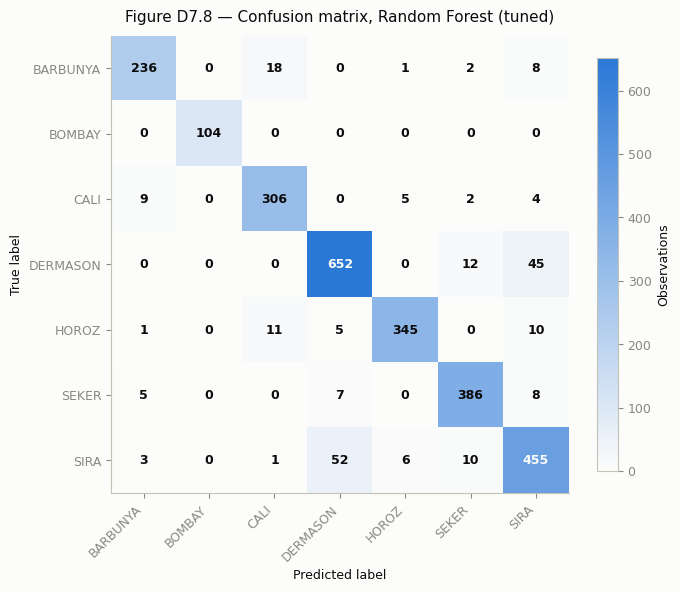

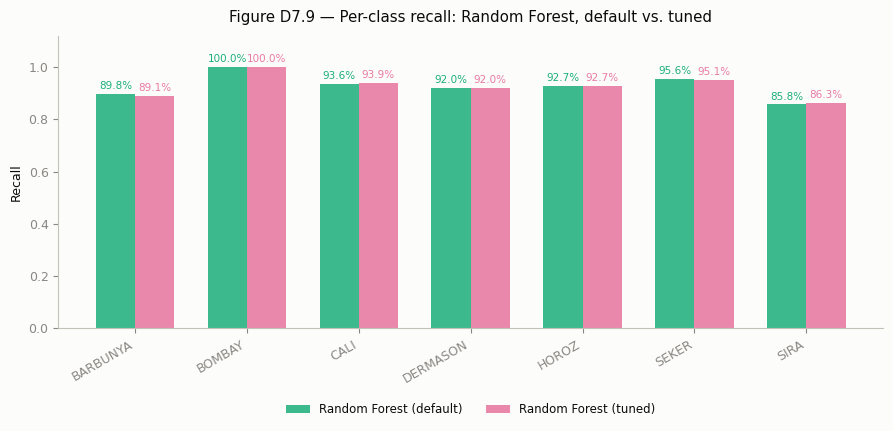

In [72]:
#  7.18 Confusion matrix, tuned Random Forest
plot_confusion_matrix(
    rf_tuned_results['confusion_matrix'],
    "Figure D7.8 — Confusion matrix, Random Forest (tuned)",
    "figD7_8_confusion_rf_tuned.png",
)


# %%
# ---- 7.19 Per-class recall: default vs. tuned Random Forest ----
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(CLASS_ORDER))
width = 0.35
bars_default = ax.bar(x - width / 2, rf_results['per_class_recall'][CLASS_ORDER], width,
                       label='Random Forest (default)', color=CLASS_COLORS['CALI'], alpha=0.85)
bars_tuned = ax.bar(x + width / 2, rf_tuned_results['per_class_recall'][CLASS_ORDER], width,
                     label='Random Forest (tuned)', color=CLASS_COLORS['HOROZ'], alpha=0.9)
ax.bar_label(bars_default,
             labels=[f"{v * 100:.1f}%" for v in rf_results['per_class_recall'][CLASS_ORDER]],
             padding=2, fontsize=7.5, color=CLASS_COLORS['CALI'])
ax.bar_label(bars_tuned,
             labels=[f"{v * 100:.1f}%" for v in rf_tuned_results['per_class_recall'][CLASS_ORDER]],
             padding=2, fontsize=7.5, color=CLASS_COLORS['HOROZ'])
ax.set_xticks(x)
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha='right')
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.12)
ax.set_title("Figure D7.9 — Per-class recall: Random Forest, default vs. tuned")
ax.legend(frameon=False, fontsize=8.5, loc='upper center',
          bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
savefig("figD7_9_per_class_recall_rf_tuned.png")
plt.show()

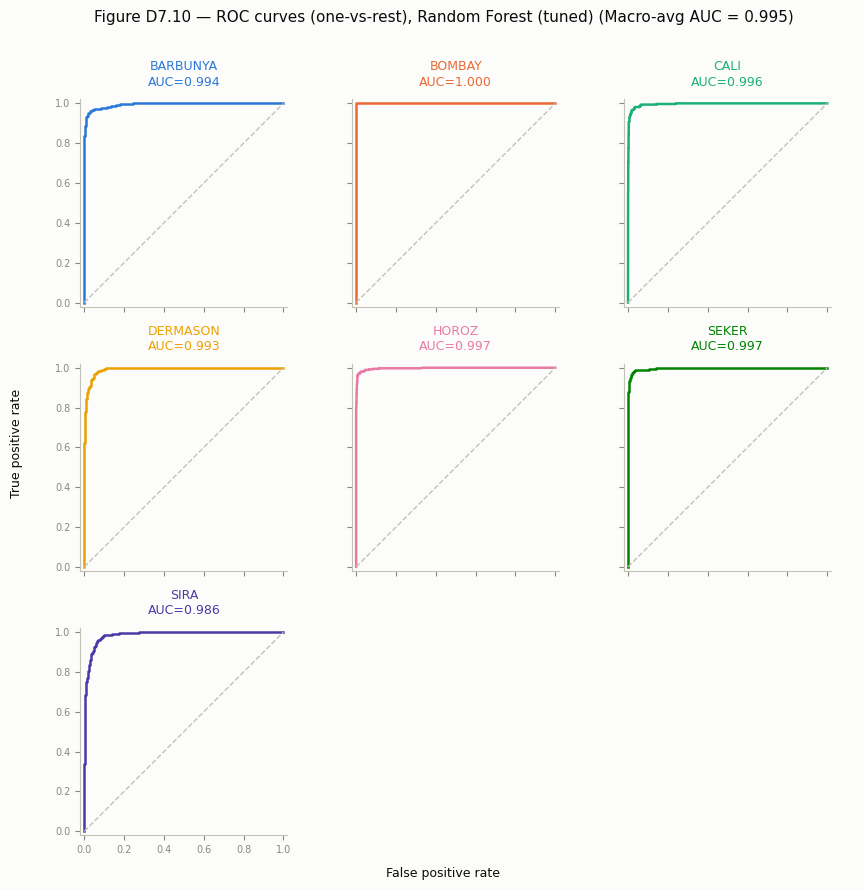

In [73]:
# 7.20 ROC curves (one-vs-rest), tuned Random Forest -- small multiples
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

proba_rf_tuned = pd.DataFrame(rf_tuned.predict_proba(X_test),
                                columns=rf_tuned.classes_)[CLASS_ORDER].values
y_test_bin = label_binarize(y_test, classes=CLASS_ORDER)

grid_cols = 3
grid_rows = int(np.ceil(len(CLASS_ORDER) / grid_cols))
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(8.5, 8.5), sharex=True, sharey=True)
axes = axes.flatten()

for i, c in enumerate(CLASS_ORDER):
    ax = axes[i]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_rf_tuned[:, i])
    class_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=CLASS_COLORS[c], linewidth=1.8)
    ax.plot([0, 1], [0, 1], color=AXIS_COLOR, linestyle='--', linewidth=1.0)
    ax.set_title(f"{c}\nAUC={class_auc:.3f}", fontsize=9, color=CLASS_COLORS[c])
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
for j in range(len(CLASS_ORDER), len(axes)):
    axes[j].axis('off')

fig.suptitle(f"Figure D7.10 — ROC curves (one-vs-rest), Random Forest (tuned) "
             f"(Macro-avg AUC = {rf_tuned_results['roc_auc_macro_ovr']:.3f})", y=1.01, fontsize=11)
fig.text(0.5, -0.01, "False positive rate", ha='center', fontsize=9)
fig.text(-0.01, 0.5, "True positive rate", va='center', rotation='vertical', fontsize=9)
plt.tight_layout()
savefig("figD7_10_roc_curve_rf_tuned.png")
plt.show()

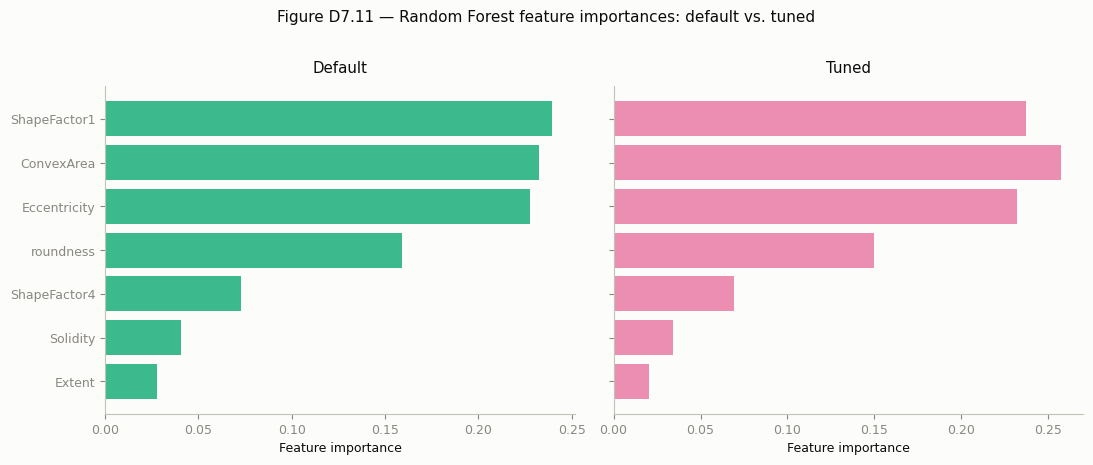


Feature importance ranking (tuned):
ConvexArea      0.2571
ShapeFactor1    0.2373
Eccentricity    0.2319
roundness       0.1497
ShapeFactor4    0.0694
Solidity        0.0341
Extent          0.0205
dtype: float64


In [74]:
# 7.21 Feature importances: default vs. tuned Random Forest

importances_default = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS)
importances_tuned = pd.Series(rf_tuned.feature_importances_, index=FEATURE_COLS)
importance_order = importances_default.sort_values(ascending=True).index

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
axes[0].barh(importance_order, importances_default[importance_order], color=CLASS_COLORS['CALI'], alpha=0.85)
axes[0].set_title("Default")
axes[0].set_xlabel("Feature importance")
axes[1].barh(importance_order, importances_tuned[importance_order], color=CLASS_COLORS['HOROZ'], alpha=0.85)
axes[1].set_title("Tuned")
axes[1].set_xlabel("Feature importance")
fig.suptitle("Figure D7.11 — Random Forest feature importances: default vs. tuned", y=1.02, fontsize=11)
plt.tight_layout()
savefig("figD7_11_feature_importance_rf_tuned.png")
plt.show()

print("\nFeature importance ranking (tuned):")
print(importances_tuned.sort_values(ascending=False).round(4))

In [75]:
# Random Forest tuning summary / working notes

print("=" * 70)
print("RANDOM FOREST TUNING SUMMARY")
print("=" * 70)
print(f"Best CV macro F1: {rf_search.best_score_:.4f} | Best params: {rf_search.best_params_}")
print(f"Test-set macro F1: default={rf_results['f1_macro']:.4f} -> "
      f"tuned={rf_tuned_results['f1_macro']:.4f} ({rf_tuning_gain:+.4f})")
print(f"Test-set macro AUC: default={rf_results['roc_auc_macro_ovr']:.4f} -> "
      f"tuned={rf_tuned_results['roc_auc_macro_ovr']:.4f}")
print(f"\nWeakest class (tuned): {rf_tuned_results['per_class_recall'].idxmin()} "
      f"(recall={rf_tuned_results['per_class_recall'].min():.4f})")
print("\nSave for the report's Modeling section: the full cv_results_ table (tuning evidence), "
      "the best_params_ dict, and the overfitting-gap comparison from 7.16 -- the case for "
      "tuning Random Forest rests more on generalization/overfitting control than on a large "
      "test-set score gain, and that distinction is worth stating explicitly.")
print("\nNext: XGBoost initial fit, then its own systematic tuning, per the team plan. Once "
      "all models are tuned, Day 9 (Evaluation) compares final configurations and Day 10 "
      "(Interpretation) compares feature importance/coefficients across at least three models.")

RANDOM FOREST TUNING SUMMARY
Best CV macro F1: 0.9408 | Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}
Test-set macro F1: default=0.9288 -> tuned=0.9286 (-0.0002)
Test-set macro AUC: default=0.9933 -> tuned=0.9948

Weakest class (tuned): SIRA (recall=0.8634)

Save for the report's Modeling section: the full cv_results_ table (tuning evidence), the best_params_ dict, and the overfitting-gap comparison from 7.16 -- the case for tuning Random Forest rests more on generalization/overfitting control than on a large test-set score gain, and that distinction is worth stating explicitly.

Next: XGBoost initial fit, then its own systematic tuning, per the team plan. Once all models are tuned, Day 9 (Evaluation) compares final configurations and Day 10 (Interpretation) compares feature importance/coefficients across at least three models.


# Random Forest Tuning. Key Insights

**Tuning's real win is a 38% smaller overfitting gap, at essentially zero cost to test performance.** The train-test accuracy gap shrinks from 0.0831 (default) to 0.0514 (tuned), driven mainly by `min_samples_leaf=4` rather than a depth cap (the winning config actually keeps `max_depth=None`). Test macro F1 barely moves (0.9288 to 0.9286, -0.0002). This is exactly the outcome the framing going in predicted: the case for tuning Random Forest here was always about generalization confidence, not a large score gain, and that's precisely what happened.

**class_weight rejects intervention for the third time in a row.** The best config uses `class_weight=None`, and the top-10 CV table is a near-even split between None/balanced/balanced_subsample with no consistent winner, a much weaker signal than Logistic Regression's clean rejection, but still no config with explicit weighting decisively beats the unweighted ones. Combined with the Logistic Regression tuning result, this is now two different model families agreeing: the 6.79x DERMASON:BOMBAY ratio doesn't need explicit correction at either the loss level (LR) or the split level (RF).

**Macro AUC actually improved (0.9933 → 0.9948) and now edges out tuned Logistic Regression's 0.9946, the best ranking quality of any model so far.** This sits alongside RF's very slightly *lower* macro F1 than tuned LR (0.9286 vs. 0.9302), a genuine nuance worth naming in the report: Random Forest ranks class probabilities marginally better, while Logistic Regression's hard classifications are marginally more accurate at the default threshold. Which one "wins" depends on which use case matters more (thresholded decisions vs. ranked confidence).

**The CV estimate (0.9408) overstates the test result (0.9286) by about a point and a half.** A normal, expected CV-vs-holdout gap, but worth stating explicitly in the report rather than quoting only the CV number as if it were the generalization estimate, the held-out test score is the one that counts.

**SIRA is now confirmed weakest across three real models in a row: LR-tuned (88.43%), RF-default (85.77%), RF-tuned (86.34%).** Tuning nudged SIRA up slightly (+0.57pp) but nowhere close to closing the gap with the other classes,three-for-three evidence this is a feature-space overlap problem, not something any amount of regularization or depth control fixes.

**Feature importances stayed compositionally stable but ConvexArea edged past ShapeFactor1 for the top spot (0.257 vs. 0.237 vs. Eccentricity's 0.232).** The same top-3 features still carry ~73% of total importance as before tuning, reassuring that the tuned model's structure agrees with the default fit's story, not a different one requiring re-interpretation.

**Where this leaves the model comparison:**
- Tuned Logistic Regression is still the single best model on macro F1 (0.9302) of everything fit so far; tuned Random Forest's edge is the smaller overfitting gap and marginally better AUC, not a higher F1.
- SIRA (and secondarily BARBUNYA) remain the two classes every model, linear or tree-based, struggles with most; XGBoost is the next real test of whether that holds a third time.
